0 - Preparação com instalação e import das principais bibliotecas para execução do projeto\
*Antes de Importar instalar com pip install (pandas, numpy, metplotlib, seabor, ipykernel, Jinja2,
ipython e notebook)\
Ou Executar pip install -r requirements.txt
*Os modulos (os, re, json, random e datetime) ja vem instalado no python

In [1]:
import os
import re
import json
import random
import jinja2
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Passo 1 - Criando Função para Gerar Dataframe sintetico e Gerando arquivo Vendas.csv

In [2]:
def gerar_dataset_vendas(n_registros=200, seed=42):
    """Gera um dataset sintético de vendas com dados intencionalmente sujos."""
    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado", "Mouse", "Headset"]
    categorias = {"Notebook": "Computadores", "Smartphone": "Celulares", "Tablet": "Celulares",
                  "Monitor": "Computadores", "Teclado": "Periféricos", "Mouse": "Periféricos",
                  "Headset": "Periféricos"}
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 51)]

    data_inicio = datetime(2024, 1, 1)
    dados = []

    for i in range(n_registros):
        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco_base = {"Notebook": 3500, "Smartphone": 2200, "Tablet": 1800,
                      "Monitor": 1200, "Teclado": 250, "Mouse": 120, "Headset": 350}[produto]
        preco = round(preco_base * random.uniform(0.85, 1.15), 2)
        data = data_inicio + timedelta(days=random.randint(0, 364))

        # Inserindo dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            quantidade = None          # valor nulo
        if random.random() < 0.04:
            preco = None               # valor nulo
        if random.random() < 0.03:
            produto = "  " + produto   # espaço extra (string suja)

        dados.append({
            "id_venda": i + 1,
            "data_venda": data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVÁLIDA",
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)

# Gerar e salvar
df_bruto = gerar_dataset_vendas()
df_bruto.to_csv("vendas.csv", index=False)
print(f"Dataset gerado com {len(df_bruto)} registros.")
print(df_bruto.head())

Dataset gerado com 200 registros.
   id_venda  data_venda      cliente     produto     categoria    regiao  \
0         1  2024-05-20  Cliente_035       Mouse   Periféricos   Sudeste   
1         2  2024-02-17  Cliente_042     Teclado   Periféricos     Norte   
2         3  2024-05-22  Cliente_022     Monitor  Computadores  Nordeste   
3         4  2024-06-21  Cliente_017  Smartphone     Celulares   Sudeste   
4         5  2024-07-12  Cliente_024       Mouse   Periféricos     Norte   

   quantidade  preco_unitario  
0         2.0          102.90  
1         7.0          214.88  
2         4.0             NaN  
3         4.0         2501.76  
4         8.0          121.30  


Passo 2 - Carregando e lendo o arquivo vendas.CSV

In [3]:
# Carregar e ler o arquivo CSV

caminho_csv = "vendas.csv"

df_carregado = pd.read_csv(caminho_csv)

print("Arquivo CSV carregado com sucesso.")
print(f"Nome do arquivo: {caminho_csv}")
print(f"Quantidade de linhas: {df_carregado.shape[0]}")
print(f"Quantidade de colunas: {df_carregado.shape[1]}")

print("\nColunas do dataset:")
print(list(df_carregado.columns))

print("\nPrimeiros registros do arquivo lido:")
display(df_carregado.head())

Arquivo CSV carregado com sucesso.
Nome do arquivo: vendas.csv
Quantidade de linhas: 200
Quantidade de colunas: 8

Colunas do dataset:
['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Primeiros registros do arquivo lido:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30


Passo 3 - Criando Cópia de segurança do DataFrame carregado\

df_bruto      = # DataFrame gerado originalmente\
df_carregado  = # DataFrame lido a partir do vendas.csv\
df_original   = # Cópia preservada para segurança



In [4]:
# Cópia de segurança do DataFrame carregado

df_original = df_carregado.copy(deep=True)

print("Cópia de segurança criada com sucesso.")
print("Registros em df_carregado:", len(df_carregado))
print("Registros em df_original:", len(df_original))

Cópia de segurança criada com sucesso.
Registros em df_carregado: 200
Registros em df_original: 200


Passo 4 Criando Função e Exibindo as informações básicas do DataFrame de vendas.

In [5]:
def inspecionar_dados(df):
    """
    Exibe informações básicas do DataFrame de vendas.
    Esta função atende ao requisito RF02 do projeto.
    """

    print("\n" + "=" * 60)
    print("INSPEÇÃO INICIAL DO DATASET")
    print("=" * 60)

    print(f"\nShape do dataset: {df.shape}")

    print("\nColunas:")
    print(list(df.columns))

    print("\nTipos de dados:")
    print(df.dtypes)

    print("\nValores nulos por coluna:")
    print(df.isnull().sum().to_string())
    
    print("\nLinhas que possuem algum valor nulo:")
    print(df[df.isnull().any(axis=1)].head(10).to_string())

    print("\nPrimeiros 5 registros:")
    print(df.head())

    print("\nEstatísticas descritivas das colunas numéricas:")
    print(df.describe())
    

In [6]:
inspecionar_dados(df_carregado)


INSPEÇÃO INICIAL DO DATASET

Shape do dataset: (200, 8)

Colunas:
['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade         6
preco_unitario    10

Linhas que possuem algum valor nulo:
    id_venda  data_venda      cliente     produto     categoria        regiao  quantidade  preco_unitario
2          3  2024-05-22  Cliente_022     Monitor  Computadores      Nordeste         4.0             NaN
34        35  2024-01-23  Cliente_048       Mouse   Periféricos  Centro-Oeste         NaN          131.86
38        39  2024-03-31  Cliente_027  

Passo 5 - Inspeção extra para analisar resultado invalidos e ou nulos

In [7]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.max_rows", 100)

print("=== VALORES NULOS POR COLUNA ===")
print(df_carregado.isnull().sum().to_string())

print("\n=== TOTAL DE LINHAS COM ALGUM VALOR NULO ===")
print(df_carregado.isnull().any(axis=1).sum())

print("\n=== LINHAS COM VALORES NULOS ===")
display(df_carregado[df_carregado.isnull().any(axis=1)].head(20))

print("\n=== DATAS INVÁLIDAS EM TEXTO ===")
print((df_carregado["data_venda"] == "DATA INVÁLIDA").sum())

print("\n=== LINHAS COM DATA INVÁLIDA ===")
display(df_carregado[df_carregado["data_venda"] == "DATA INVÁLIDA"].head(20))

=== VALORES NULOS POR COLUNA ===
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade         6
preco_unitario    10

=== TOTAL DE LINHAS COM ALGUM VALOR NULO ===
16

=== LINHAS COM VALORES NULOS ===


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
34,35,2024-01-23,Cliente_048,Mouse,Periféricos,Centro-Oeste,NaN,131.86
38,39,2024-03-31,Cliente_027,Headset,Periféricos,Sul,3.0,NaN
39,40,2024-02-25,Cliente_030,Tablet,Celulares,Nordeste,3.0,NaN
41,42,2024-10-01,Cliente_038,Mouse,Periféricos,Nordeste,9.0,NaN
43,44,2024-08-11,Cliente_048,Smartphone,Celulares,Sul,NaN,1899.30
62,63,2024-05-06,Cliente_043,Headset,Periféricos,Sudeste,1.0,NaN
69,70,2024-12-08,Cliente_014,Headset,Periféricos,Nordeste,8.0,NaN
75,76,2024-06-03,Cliente_036,Tablet,Celulares,Nordeste,NaN,1724.88
76,77,2024-09-08,Cliente_022,Mouse,Periféricos,Sul,3.0,NaN



=== DATAS INVÁLIDAS EM TEXTO ===
4

=== LINHAS COM DATA INVÁLIDA ===


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
56,57,DATA INVÁLIDA,Cliente_049,Monitor,Computadores,Norte,1.0,1094.46
91,92,DATA INVÁLIDA,Cliente_027,Notebook,Computadores,Sudeste,1.0,3996.80
94,95,DATA INVÁLIDA,Cliente_047,Headset,Periféricos,Nordeste,2.0,326.51
167,168,DATA INVÁLIDA,Cliente_023,Teclado,Periféricos,Sul,9.0,213.73


Passo 6 - Criando Função de Limpesa e Ajuste de dados invalidos e nulos


In [8]:
def limpar_dados(df):
    """
    Limpa e trata o DataFrame de vendas.

    Tratamentos realizados:
    1. Remove espaços extras das colunas de texto.
    2. Converte data_venda para datetime.
    3. Remove linhas com datas inválidas.
    4. Substitui quantidade nula por 1.
    5. Substitui preco_unitario nulo pela média do preço do mesmo produto.
    6. Remove linhas em que não foi possível calcular preço médio do produto.
    7. Ajusta os tipos numéricos finais.
    """

    n_inicial = len(df)
    relatorio = {}

    # 1. Remover espaços extras em colunas de texto
    colunas_texto = ["data_venda", "cliente", "produto", "categoria", "regiao"]

    for col in colunas_texto:
        df[col] = df[col].astype(str).str.strip()

    # 2. Converter data_venda para datetime
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")

    # 3. Remover datas inválidas
    n_datas_invalidas = df["data_venda"].isnull().sum()
    df = df.dropna(subset=["data_venda"]).copy()

    relatorio["datas_invalidas_removidas"] = int(n_datas_invalidas)

    # 4. Identificar valores nulos antes da imputação
    quantidades_nulas = df["quantidade"].isnull().sum()
    precos_nulos = df["preco_unitario"].isnull().sum()

    # 5. Substituir quantidade nula por 1
    df["quantidade"] = df["quantidade"].fillna(1)

    # 6. Calcular média de preço por produto
    media_preco_por_produto = df.groupby("produto")["preco_unitario"].transform("mean")

    # 7. Substituir preço nulo pela média do mesmo produto
    df["preco_unitario"] = df["preco_unitario"].fillna(media_preco_por_produto)

    # 8. Verificar preços que continuaram nulos
    precos_sem_media = df["preco_unitario"].isnull().sum()

    # 9. Remover linhas sem preço recuperável
    df = df.dropna(subset=["preco_unitario"]).copy()

    relatorio["quantidades_nulas_substituidas"] = int(quantidades_nulas)
    relatorio["precos_nulos_encontrados"] = int(precos_nulos)
    relatorio["precos_nulos_substituidos_por_media_do_produto"] = int(precos_nulos - precos_sem_media)
    relatorio["linhas_removidas_por_preco_sem_media"] = int(precos_sem_media)

    # 10. Garantir tipos numéricos corretos
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    # 11. Relatório final
    n_final = len(df)

    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = n_final
    relatorio["registros_removidos_total"] = n_inicial - n_final

    print("\n=== RELATÓRIO DE LIMPEZA ===")

    for chave, valor in relatorio.items():
        print(f"{chave}: {valor}")

    print("\nValores nulos após a limpeza:")
    print(df.isnull().sum().to_string())

    print("\nTipos de dados após a limpeza:")
    print(df.dtypes)

    return df, relatorio

Passo 7 - Executando Limpesa do DataFrame Carregado

In [9]:
df_limpo, relatorio_limpeza = limpar_dados(df_carregado.copy())

display(df_limpo.head())


=== RELATÓRIO DE LIMPEZA ===
datas_invalidas_removidas: 4
quantidades_nulas_substituidas: 6
precos_nulos_encontrados: 10
precos_nulos_substituidos_por_media_do_produto: 10
linhas_removidas_por_preco_sem_media: 0
registros_iniciais: 200
registros_finais: 196
registros_removidos_total: 4

Valores nulos após a limpeza:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        0
preco_unitario    0

Tipos de dados após a limpeza:
id_venda                   int64
data_venda        datetime64[us]
cliente                      str
produto                      str
categoria                    str
regiao                       str
quantidade                 int64
preco_unitario           float64
dtype: object


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.900000
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.880000
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4,1204.981481
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.760000
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.300000


In [10]:
# Lendo DataFrame limpo para análise
df_limpo


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.900000
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.880000
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4,1204.981481
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.760000
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.300000
...,...,...,...,...,...,...,...,...
195,196,2024-07-15,Cliente_021,Notebook,Computadores,Norte,1,3279.720000
196,197,2024-03-22,Cliente_002,Mouse,Periféricos,Sudeste,6,108.830000
197,198,2024-05-03,Cliente_042,Monitor,Computadores,Centro-Oeste,9,1184.600000
198,199,2024-02-25,Cliente_024,Tablet,Celulares,Sudeste,9,1534.420000


Passo 9 - Analise de clientes Unicos e Quantidade de Venda por cliente

In [11]:
quantidade_clientes_unicos = df_limpo["cliente"].nunique()
total_registros = len(df_limpo)


print(f"Quantidade de clientes únicos: {quantidade_clientes_unicos}")

tabela_clientes = (
    df_limpo["cliente"]
    .value_counts()
    .reset_index()
)

tabela_clientes.columns = ["cliente", "quantidade_de_vendas"]
tabela_clientes["quantidade_de_vendas"] = tabela_clientes["quantidade_de_vendas"].apply(lambda x: "1 Venda" if x == 1 else f"{x} Vendas")


display(tabela_clientes)

Quantidade de clientes únicos: 49


,cliente,quantidade_de_vendas
0,Cliente_024,8 Vendas
1,Cliente_021,8 Vendas
2,Cliente_015,8 Vendas
3,Cliente_035,7 Vendas
4,Cliente_043,7 Vendas
5,Cliente_048,7 Vendas
6,Cliente_005,6 Vendas
7,Cliente_023,6 Vendas
8,Cliente_044,6 Vendas
9,Cliente_007,6 Vendas


Passo 10 - Criando Função para Criar Colunas derivadas no DataSet df_limpo
* Colunas Criadas
1. `receita_total` - Esta coluna apresenta o valor total do produto vendido no ticket
2. `mes` - Esta coluna apresenta o mês do ano em forma numerica da venda
3. `mes_nome` - Esta coluna apresenta o mês do ano em forma textual da venda
4. `trimestre` - Esta coluna apresenta trimeste do ano abreviado 
5. `ano` - Esta coluna apresenta o ano em forma numerica
6. `faixa_receita_item` - Esta coluna apresenta a faixa de receita do item segundo a regra de classificação
7. `preco_medio_item`- Esta coluna apresenta o preço medio do item
8. `comparacao_preco_media` - Esta coluna apresenta o status do preço medio do item na venda (Abaixo, Acima ou Na media)
9. `percentual_diferenca_media` - Esta coluna apresenta o percentual de diferença do preço do item na venda

In [38]:
def criar_colunas_derivadas(df):
    """Cria colunas calculadas e derivadas a partir do dataset limpo."""

    from IPython.display import display

    df = df.copy()

    # Função para exibir valores monetários no padrão brasileiro
    def formatar_moeda_br(valor):
        if pd.isna(valor):
            return ""
        return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

    # Função auxiliar para exibir DataFrames alinhados à esquerda nas próximas células
    def exibir_df(tabela, linhas=20):
        display(
            tabela
            .head(linhas)
            .style
            .set_properties(**{"text-align": "left"})
            .set_table_styles(
                [
                    {
                        "selector": "th",
                        "props": [("text-align", "left")]
                    }
                ]
            )
        )

    # Disponibiliza a função exibir_df para uso em outras células do notebook
    globals()["exibir_df"] = exibir_df

    # Garantir que data_venda esteja em formato datetime antes dos cálculos
    df["data_venda"] = pd.to_datetime(
        df["data_venda"],
        errors="coerce",
        dayfirst=True
    )

    # Garantir que quantidade e preço unitário estejam numéricos
    df["quantidade"] = pd.to_numeric(df["quantidade"], errors="coerce")
    df["preco_unitario"] = pd.to_numeric(df["preco_unitario"], errors="coerce")

    # Receita total por linha
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Ajustar valores monetários para duas casas decimais
    df["preco_unitario"] = df["preco_unitario"].round(2)
    df["receita_total"] = df["receita_total"].round(2)

    # Colunas de data
    df["mes"] = df["data_venda"].dt.month

    meses_pt_br = {
        1: "Janeiro",
        2: "Fevereiro",
        3: "Março",
        4: "Abril",
        5: "Maio",
        6: "Junho",
        7: "Julho",
        8: "Agosto",
        9: "Setembro",
        10: "Outubro",
        11: "Novembro",
        12: "Dezembro"
    }

    df["mes_nome"] = df["mes"].map(meses_pt_br)

    # Trimestre usando T em vez de Q
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"T{q}")

    df["ano"] = df["data_venda"].dt.year

    # Classificação da receita por item
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000
    ]

    classificacoes = [
        "Baixo Valor",
        "Médio Valor",
        "Alto Valor"
    ]

    df["faixa_receita_item"] = np.select(
        condicoes,
        classificacoes,
        default="Não Classificado"
    )

    # Média do preço unitário por produto
    df["preco_medio_item"] = (
        df.groupby("produto")["preco_unitario"]
        .transform("mean")
        .round(2)
    )

    # Comparação do preço da venda com a média do produto
    df["comparacao_preco_media"] = np.select(
        [
            df["preco_unitario"] > df["preco_medio_item"],
            df["preco_unitario"] < df["preco_medio_item"],
            df["preco_unitario"] == df["preco_medio_item"]
        ],
        [
            "Acima",
            "Abaixo",
            "Na média"
        ],
        default="Não classificado"
    )

    # Percentual acima ou abaixo da média
    df["percentual_diferenca_media"] = (
        (df["preco_unitario"] - df["preco_medio_item"]) / df["preco_medio_item"] * 100
    ).round(2)

    # Formatar percentual no padrão brasileiro com símbolo %
    df["percentual_diferenca_media"] = df["percentual_diferenca_media"].apply(
        lambda x: f"{x:.2f} %".replace(".", ",") if pd.notna(x) else ""
    )

    # Criar coluna de data no padrão brasileiro apenas para exibição
    df["data_venda_br"] = df["data_venda"].dt.strftime("%d/%m/%Y")

    print("\n=== COLUNAS DERIVADAS CRIADAS ===")

    # Mostrar todas as colunas do DataFrame
    colunas_exibicao = list(df.columns)

    # Colocar a data formatada logo depois da data original
    if "data_venda_br" in colunas_exibicao:
        colunas_exibicao.remove("data_venda_br")

        if "data_venda" in colunas_exibicao:
            posicao_data = colunas_exibicao.index("data_venda") + 1
            colunas_exibicao.insert(posicao_data, "data_venda_br")
        else:
            colunas_exibicao.insert(0, "data_venda_br")

    # Formatação das colunas para exibição
    formatacao_colunas = {}

    if "quantidade" in df.columns:
        formatacao_colunas["quantidade"] = "{:.0f}"

    if "preco_unitario" in df.columns:
        formatacao_colunas["preco_unitario"] = formatar_moeda_br

    if "receita_total" in df.columns:
        formatacao_colunas["receita_total"] = formatar_moeda_br

    if "preco_medio_item" in df.columns:
        formatacao_colunas["preco_medio_item"] = formatar_moeda_br

    display(
        df[colunas_exibicao]
        .head()
        .style
        .format(formatacao_colunas)
        .set_properties(**{"text-align": "left"})
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [("text-align", "left")]
                }
            ]
        )
    )

    return df

Passo 11 - Criando Colunas Derivadas no df_limpo

In [39]:
df_limpo = criar_colunas_derivadas(df_limpo)


=== COLUNAS DERIVADAS CRIADAS ===


,id_venda,data_venda,data_venda_br,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item,preco_medio_item,comparacao_preco_media,percentual_diferenca_media,cliente_valido,produto_valido,categoria_valida,regiao_valida
0,1,2024-05-20 00:00:00,20/05/2024,Cliente_035,Mouse,Periféricos,Sudeste,2,"R$ 102,90","R$ 205,80",5,Maio,T2,2024,Baixo Valor,"R$ 121,82",Abaixo,"-15,53 %",True,True,True,True
1,2,2024-02-17 00:00:00,17/02/2024,Cliente_042,Teclado,Periféricos,Norte,7,"R$ 214,88","R$ 1.504,16",2,Fevereiro,T1,2024,Médio Valor,"R$ 242,19",Abaixo,"-11,28 %",True,True,True,True
2,3,2024-05-22 00:00:00,22/05/2024,Cliente_022,Monitor,Computadores,Nordeste,4,"R$ 1.204,98","R$ 4.819,92",5,Maio,T2,2024,Médio Valor,"R$ 1.204,98",Na média,"0,00 %",True,True,True,True
3,4,2024-06-21 00:00:00,21/06/2024,Cliente_017,Smartphone,Celulares,Sudeste,4,"R$ 2.501,76","R$ 10.007,04",6,Junho,T2,2024,Alto Valor,"R$ 2.167,12",Acima,"15,44 %",True,True,True,True
4,5,2024-07-12 00:00:00,12/07/2024,Cliente_024,Mouse,Periféricos,Norte,8,"R$ 121,30","R$ 970,40",7,Julho,T3,2024,Médio Valor,"R$ 121,82",Abaixo,"-0,43 %",True,True,True,True


Passo 12 - Criar Função de Expressões Regulares para Limpeza de Dados

In [14]:
# ============================================================
# FUNÇÃO: LIMPEZA E PADRONIZAÇÃO DE STRINGS COM REGEX
# RF13 - Expressões Regulares para Limpeza de Dados
# ============================================================

import re
import unicodedata


def limpar_strings_com_regex(df):
    """
    Limpa e padroniza colunas de texto do dataset de vendas.

    A função:
    - remove espaços extras;
    - remove caracteres especiais indevidos;
    - padroniza cliente como Cliente_XXX;
    - padroniza produto;
    - padroniza categoria;
    - padroniza região;
    - valida cliente, produto, categoria e região;
    - corrige categoria com base no produto;
    - retorna o DataFrame ajustado.

    Observação:
    Esta função não trata nulos numéricos nem datas inválidas.
    Essas etapas pertencem ao método .limpar() da classe AnalisadorDeVendas.
    """

    df = df.copy()

    # ========================================================
    # VALIDAÇÃO DE COLUNAS NECESSÁRIAS
    # ========================================================

    colunas_necessarias = ["cliente", "produto", "categoria", "regiao"]

    colunas_faltantes = [
        coluna for coluna in colunas_necessarias
        if coluna not in df.columns
    ]

    if colunas_faltantes:
        raise KeyError(
            f"As seguintes colunas são necessárias para limpeza com regex: {colunas_faltantes}"
        )

    # Guarda valores originais para relatório de alterações
    valores_originais = {
        coluna: df[coluna].copy()
        for coluna in colunas_necessarias
    }

    # ========================================================
    # FUNÇÕES AUXILIARES
    # ========================================================

    def remover_acentos(texto):
        """
        Remove acentos para facilitar comparações internas.
        Exemplo: Periféricos -> Perifericos
        """

        texto = str(texto)

        return "".join(
            caractere for caractere in unicodedata.normalize("NFKD", texto)
            if not unicodedata.combining(caractere)
        )

    def limpar_texto_base(valor):
        """
        Aplica limpeza textual básica usando regex.
        Mantém letras, números, underline, hífen, espaços e acentos.
        """

        if pd.isna(valor):
            return ""

        texto = str(valor)

        # Remove quebras de linha e tabulações
        texto = re.sub(r"[\n\r\t]+", " ", texto)

        # Remove caracteres especiais indevidos
        texto = re.sub(r"[^\w\s\-]", "", texto, flags=re.UNICODE)

        # Corrige espaços ao redor de hífen
        texto = re.sub(r"\s*-\s*", "-", texto)

        # Remove espaços repetidos
        texto = re.sub(r"\s+", " ", texto)

        return texto.strip()

    def gerar_chave_padrao(valor):
        """
        Cria uma chave simples para comparação:
        - minúscula;
        - sem acento;
        - sem underline/hífen como separadores.
        """

        texto = limpar_texto_base(valor)
        texto = remover_acentos(texto)
        texto = texto.lower()

        texto = re.sub(r"[_\-]+", " ", texto)
        texto = re.sub(r"\s+", " ", texto)

        return texto.strip()

    def padronizar_cliente(valor):
        """
        Padroniza cliente no formato Cliente_XXX.
        Exemplos aceitos:
        - Cliente_035
        - cliente 35
        - Cliente-35
        - CLIENTE_035
        """

        texto = limpar_texto_base(valor)

        if texto == "":
            return "Cliente_Nao_Identificado"

        numero_cliente = re.search(r"\d+", texto)

        if numero_cliente:
            numero = int(numero_cliente.group())
            return f"Cliente_{numero:03d}"

        return texto

    def padronizar_produto(valor):
        """
        Padroniza nomes de produtos conhecidos.
        """

        mapa_produtos = {
            "notebook": "Notebook",
            "smartphone": "Smartphone",
            "smart phone": "Smartphone",
            "tablet": "Tablet",
            "monitor": "Monitor",
            "teclado": "Teclado",
            "mouse": "Mouse",
            "headset": "Headset"
        }

        chave = gerar_chave_padrao(valor)

        if chave == "":
            return "Produto Não Informado"

        return mapa_produtos.get(chave, limpar_texto_base(valor).title())

    def padronizar_categoria(valor):
        """
        Padroniza categorias conhecidas.
        """

        mapa_categorias = {
            "computadores": "Computadores",
            "computador": "Computadores",
            "celulares": "Celulares",
            "celular": "Celulares",
            "perifericos": "Periféricos",
            "periferico": "Periféricos",
            "outros": "Outros"
        }

        chave = gerar_chave_padrao(valor)

        if chave == "":
            return "Outros"

        return mapa_categorias.get(chave, limpar_texto_base(valor).title())

    def padronizar_regiao(valor):
        """
        Padroniza regiões brasileiras usadas no dataset.
        """

        mapa_regioes = {
            "norte": "Norte",
            "sul": "Sul",
            "sudeste": "Sudeste",
            "nordeste": "Nordeste",
            "centro oeste": "Centro-Oeste",
            "centrooeste": "Centro-Oeste"
        }

        chave = gerar_chave_padrao(valor)

        if chave == "":
            return "Região Não Informada"

        return mapa_regioes.get(chave, limpar_texto_base(valor).title())

    # ========================================================
    # PADRONIZAÇÃO DAS COLUNAS PRINCIPAIS
    # ========================================================

    df["cliente"] = df["cliente"].apply(padronizar_cliente)
    df["produto"] = df["produto"].apply(padronizar_produto)
    df["categoria"] = df["categoria"].apply(padronizar_categoria)
    df["regiao"] = df["regiao"].apply(padronizar_regiao)

    # ========================================================
    # CORREÇÃO DA CATEGORIA COM BASE NO PRODUTO
    # ========================================================

    categoria_por_produto = {
        "Notebook": "Computadores",
        "Monitor": "Computadores",
        "Smartphone": "Celulares",
        "Tablet": "Celulares",
        "Teclado": "Periféricos",
        "Mouse": "Periféricos",
        "Headset": "Periféricos"
    }

    df["categoria"] = df.apply(
        lambda linha: categoria_por_produto.get(
            linha["produto"],
            linha["categoria"]
        ),
        axis=1
    )

    # ========================================================
    # VALIDAÇÕES
    # ========================================================

    produtos_validos = set(categoria_por_produto.keys())

    categorias_validas = {
        "Computadores",
        "Celulares",
        "Periféricos",
        "Outros"
    }

    regioes_validas = {
        "Norte",
        "Sul",
        "Sudeste",
        "Nordeste",
        "Centro-Oeste"
    }

    df["cliente_valido"] = df["cliente"].apply(
        lambda valor: bool(re.fullmatch(r"Cliente_\d{3}", str(valor)))
    )

    df["produto_valido"] = df["produto"].isin(produtos_validos)

    df["categoria_valida"] = df["categoria"].isin(categorias_validas)

    df["regiao_valida"] = df["regiao"].isin(regioes_validas)

    # ========================================================
    # RELATÓRIO DA LIMPEZA
    # ========================================================

    alteracoes = {}

    for coluna in colunas_necessarias:
        alteracoes[coluna] = int(
            (
                valores_originais[coluna].astype(str)
                != df[coluna].astype(str)
            ).sum()
        )

    print("\n=== LIMPEZA E PADRONIZAÇÃO COM REGEX ===")

    print("Alterações realizadas por coluna:")
    for coluna, quantidade in alteracoes.items():
        print(f"- {coluna}: {quantidade} ajuste(s)")

    print("\nValidações após padronização:")
    print(f"- Clientes inválidos: {(~df['cliente_valido']).sum()}")
    print(f"- Produtos inválidos: {(~df['produto_valido']).sum()}")
    print(f"- Categorias inválidas: {(~df['categoria_valida']).sum()}")
    print(f"- Regiões inválidas: {(~df['regiao_valida']).sum()}")

    return df

In [15]:
df_limpo = limpar_strings_com_regex(df_limpo)

display(df_limpo[["cliente", "cliente_valido"]].head())


=== LIMPEZA E PADRONIZAÇÃO COM REGEX ===
Alterações realizadas por coluna:
- cliente: 0 ajuste(s)
- produto: 0 ajuste(s)
- categoria: 0 ajuste(s)
- regiao: 0 ajuste(s)

Validações após padronização:
- Clientes inválidos: 0
- Produtos inválidos: 0
- Categorias inválidas: 0
- Regiões inválidas: 0


,cliente,cliente_valido
0,Cliente_035,True
1,Cliente_042,True
2,Cliente_022,True
3,Cliente_017,True
4,Cliente_024,True


Passo 13 - Criar Função de Ordem Superior + Lambda destonto Top 10 cliente Faturamento

In [ ]:
# ============================================================
# RF11 - FUNÇÃO DE ORDEM SUPERIOR + LAMBDA
# DESCONTO PARA OS 10 CLIENTES COM MAIOR FATURAMENTO EM 2024
# USANDO df_limpo
# ============================================================

from pathlib import Path
import pandas as pd
from IPython.display import display


# ============================================================
# FUNÇÃO DE ORDEM SUPERIOR
# ============================================================

def processar_coluna(df, coluna, funcao_transformacao, nova_coluna=None):
    """
    Aplica uma função de transformação em uma coluna do DataFrame.

    Esta função atende ao requisito de função de ordem superior,
    pois recebe outra função como argumento.
    """

    df = df.copy()

    if coluna not in df.columns:
        raise KeyError(f"A coluna '{coluna}' não existe no DataFrame.")

    if nova_coluna is None:
        nova_coluna = f"{coluna}_processada"

    df[nova_coluna] = df[coluna].apply(funcao_transformacao)

    print(f"Coluna '{nova_coluna}' criada com sucesso.")

    return df


# Garante que a função fique disponível para outras células do notebook
globals()["processar_coluna"] = processar_coluna


# ============================================================
# FUNÇÃO PRINCIPAL DO RELATÓRIO DE DESCONTO
# ============================================================

def gerar_desconto_top10_clientes_df_limpo(ano_referencia=2024, pasta_outputs="outputs"):
    """
    Gera relatório com os 10 clientes de maior faturamento no ano informado
    usando diretamente o DataFrame df_limpo.

    Regra de desconto:
    - abaixo de R$ 20.000,00: 0%
    - de R$ 20.000,00 até R$ 50.000,00: 5%
    - acima de R$ 50.000,00: 10%

    Usa:
    - df_limpo
    - receita_total
    - processar_coluna()
    - lambda para definir o percentual de desconto
    """

    # ========================================================
    # VALIDAÇÕES INICIAIS
    # ========================================================

    if "df_limpo" not in globals():
        raise NameError("O DataFrame df_limpo ainda não existe. Execute o pipeline antes.")

    colunas_necessarias = ["cliente", "receita_total"]

    for coluna in colunas_necessarias:
        if coluna not in df_limpo.columns:
            raise KeyError(f"A coluna obrigatória '{coluna}' não existe em df_limpo.")

    df_base = df_limpo.copy()

    # ========================================================
    # FUNÇÕES AUXILIARES
    # ========================================================

    def converter_valor_financeiro(valor):
        """
        Converte valor financeiro para número.

        Aceita:
        - 15000.50
        - "15000.50"
        - "R$ 15.000,50"
        - "15.000,50"
        """

        if pd.isna(valor):
            return pd.NA

        if isinstance(valor, (int, float)):
            return float(valor)

        texto = str(valor).strip()
        texto = texto.replace("R$", "")
        texto = texto.replace(" ", "")

        # Padrão brasileiro: 15.000,50
        if "," in texto:
            texto = texto.replace(".", "")
            texto = texto.replace(",", ".")

        try:
            return float(texto)
        except ValueError:
            return pd.NA

    def formatar_moeda_br(valor):
        if pd.isna(valor):
            return ""

        return (
            f"R$ {valor:,.2f}"
            .replace(",", "X")
            .replace(".", ",")
            .replace("X", ".")
        )

    # ========================================================
    # GARANTE O ANO
    # ========================================================

    if "ano" not in df_base.columns:
        if "data_venda" not in df_base.columns:
            raise KeyError("df_limpo precisa ter a coluna 'ano' ou 'data_venda'.")

        df_base["data_venda"] = pd.to_datetime(
            df_base["data_venda"],
            errors="coerce",
            dayfirst=True
        )

        df_base["ano"] = df_base["data_venda"].dt.year

    df_base["ano"] = pd.to_numeric(
        df_base["ano"],
        errors="coerce"
    )

    # ========================================================
    # GARANTE RECEITA_TOTAL NUMÉRICA
    # ========================================================

    df_base["receita_total"] = df_base["receita_total"].apply(
        converter_valor_financeiro
    )

    df_base["receita_total"] = pd.to_numeric(
        df_base["receita_total"],
        errors="coerce"
    )

    df_base = df_base.dropna(
        subset=["cliente", "receita_total", "ano"]
    )

    df_base["ano"] = df_base["ano"].astype(int)

    # ========================================================
    # FILTRA O ANO DE REFERÊNCIA
    # ========================================================

    df_ano = df_base[
        df_base["ano"] == ano_referencia
    ].copy()

    if df_ano.empty:
        raise ValueError(f"Não há dados válidos para o ano {ano_referencia}.")

    # ========================================================
    # AGRUPA FATURAMENTO POR CLIENTE
    # ========================================================

    faturamento_clientes = (
        df_ano
        .groupby("cliente", as_index=False)["receita_total"]
        .sum()
        .rename(columns={"receita_total": "faturamento_ano"})
    )

    faturamento_clientes = faturamento_clientes.sort_values(
        "faturamento_ano",
        ascending=False
    )

    # ========================================================
    # SELECIONA OS 10 MAIORES CLIENTES
    # ========================================================

    top10_clientes = faturamento_clientes.head(10).copy()

    top10_clientes["ranking"] = range(1, len(top10_clientes) + 1)

    top10_clientes["posicao"] = top10_clientes["ranking"].apply(
        lambda ranking: "🏆 1º" if ranking == 1 else f"{ranking}º"
    )

    # ========================================================
    # APLICA DESCONTO COM processar_coluna() + lambda
    # ========================================================

    regra_desconto = lambda valor: (
        0.00 if valor < 20000
        else 0.05 if valor <= 50000
        else 0.10
    )

    top10_clientes = processar_coluna(
        df=top10_clientes,
        coluna="faturamento_ano",
        funcao_transformacao=regra_desconto,
        nova_coluna="desconto"
    )

    # ========================================================
    # CALCULA VALORES DO DESCONTO
    # ========================================================

    top10_clientes["valor_desconto"] = (
        top10_clientes["faturamento_ano"] * top10_clientes["desconto"]
    )

    top10_clientes["faturamento_com_desconto"] = (
        top10_clientes["faturamento_ano"] - top10_clientes["valor_desconto"]
    )

    # ========================================================
    # FORMATAÇÃO BR
    # ========================================================

    top10_clientes["desconto_percentual"] = top10_clientes["desconto"].apply(
        lambda valor: f"{valor:.0%}"
    )

    top10_clientes["faturamento_ano_br"] = top10_clientes["faturamento_ano"].apply(
        formatar_moeda_br
    )

    top10_clientes["valor_desconto_br"] = top10_clientes["valor_desconto"].apply(
        formatar_moeda_br
    )

    top10_clientes["faturamento_com_desconto_br"] = (
        top10_clientes["faturamento_com_desconto"].apply(formatar_moeda_br)
    )

    # ========================================================
    # RELATÓRIO FINAL
    # ========================================================

    relatorio_desconto_top10_clientes = top10_clientes[
        [
            "posicao",
            "cliente",
            "faturamento_ano_br",
            "desconto_percentual",
            "valor_desconto_br",
            "faturamento_com_desconto_br"
        ]
    ].copy()

    print(f"\n=== TOP 10 CLIENTES COM MAIOR FATURAMENTO EM {ano_referencia} ===")

    display(
        relatorio_desconto_top10_clientes
        .style
        .hide(axis="index")
        .set_properties(**{"text-align": "left"})
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [("text-align", "left")]
                }
            ]
        )
    )

    # ========================================================
    # EXPORTAÇÃO CSV
    # ========================================================

    pasta_outputs = Path(pasta_outputs)
    pasta_outputs.mkdir(exist_ok=True)

    arquivo_csv = (
        pasta_outputs / f"relatorio_desconto_top10_clientes_{ano_referencia}.csv"
    )

    relatorio_desconto_top10_clientes.to_csv(
        arquivo_csv,
        index=False,
        encoding="utf-8-sig"
    )

    print("\nRelatório de desconto dos Top 10 clientes exportado para:")
    print(arquivo_csv.resolve())

    return relatorio_desconto_top10_clientes

In [17]:
relatorio_desconto_top10_clientes_2024 = gerar_desconto_top10_clientes_df_limpo(
    ano_referencia=2024,
    pasta_outputs="outputs"
)

Coluna 'desconto' criada com sucesso.

=== TOP 10 CLIENTES COM MAIOR FATURAMENTO EM 2024 ===


posicao,cliente,faturamento_ano_br,desconto_percentual,valor_desconto_br,faturamento_com_desconto_br
🏆 1º,Cliente_015,"R$ 82.964,76",10%,"R$ 8.296,48","R$ 74.668,28"
2º,Cliente_035,"R$ 75.402,52",10%,"R$ 7.540,25","R$ 67.862,27"
3º,Cliente_048,"R$ 64.324,93",10%,"R$ 6.432,49","R$ 57.892,44"
4º,Cliente_024,"R$ 57.381,21",10%,"R$ 5.738,12","R$ 51.643,09"
5º,Cliente_006,"R$ 50.249,74",10%,"R$ 5.024,97","R$ 45.224,77"
6º,Cliente_004,"R$ 50.106,56",10%,"R$ 5.010,66","R$ 45.095,90"
7º,Cliente_023,"R$ 46.863,73",5%,"R$ 2.343,19","R$ 44.520,54"
8º,Cliente_030,"R$ 45.659,41",5%,"R$ 2.282,97","R$ 43.376,44"
9º,Cliente_032,"R$ 45.532,00",5%,"R$ 2.276,60","R$ 43.255,40"
10º,Cliente_044,"R$ 43.513,88",5%,"R$ 2.175,69","R$ 41.338,19"



Relatório de desconto dos Top 10 clientes exportado para:
C:\Users\renat\OneDrive\Documentos\SENAI\MINIPROJETO\salesinsight-py\outputs\relatorio_desconto_top10_clientes_2024.csv


Passo 14 - Criando Função para Calcular Metricas de Vendas (Por Mês, Top Produtos, Por Categoria, Por Região e Por Trimeste)

In [18]:
def calcular_metricas(df):
    """Calcula e retorna métricas agregadas do dataset."""

    metricas = {}

    por_mes = df.groupby("mes").agg(
        receita_total=("receita_total", "sum"),
        quantidade=("quantidade", "sum"),
        n_vendas=("id_venda", "count")
    ).reset_index().sort_values("mes")

    metricas["por_mes"] = por_mes

    top_produtos = (
        df.groupby("produto")["receita_total"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    metricas["top_produtos"] = top_produtos

    por_categoria = (
        df.groupby("categoria")["receita_total"]
        .sum()
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    metricas["por_categoria"] = por_categoria

    por_regiao = df.groupby("regiao").agg(
        receita_total=("receita_total", "sum"),
        media_ticket=("receita_total", "mean")
    ).reset_index().sort_values("receita_total", ascending=False)
    
    metricas["por_regiao"] = por_regiao
    
    por_trimestre = df.groupby("trimestre").agg(
        receita_total=("receita_total", "sum"),
        media_ticket=("receita_total", "mean")
    ).reset_index().sort_values("receita_total", ascending=False)

    metricas["por_trimestre"] = por_trimestre

    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        display(tabela)

    return metricas

In [19]:
metricas = calcular_metricas(df_limpo)


=== POR MES ===


,mes,receita_total,quantidade,n_vendas
0,1,47301.20,46,10
1,2,75342.20,94,16
2,3,128796.85,92,19
3,4,103611.52,75,15
4,5,132570.78,100,17
5,6,119059.73,76,16
6,7,110935.66,99,19
7,8,142461.63,83,15
8,9,90992.72,66,11
9,10,138446.52,127,21



=== TOP PRODUTOS ===


,produto,receita_total
0,Notebook,381173.55
1,Tablet,360275.04
2,Smartphone,236876.48
3,Monitor,195286.34
4,Headset,62822.19



=== POR CATEGORIA ===


,categoria,receita_total
0,Celulares,597151.52
1,Computadores,576459.89
2,Periféricos,112082.91



=== POR REGIAO ===


,regiao,receita_total,media_ticket
3,Sudeste,331034.10,7698.467442
2,Norte,252849.55,7023.598611
0,Centro-Oeste,248273.50,5911.273810
1,Nordeste,235677.50,5891.937500
4,Sul,217859.67,6224.562000



=== POR TRIMESTRE ===


,trimestre,receita_total,media_ticket
1,T2,355242.03,7400.875625
2,T3,344390.01,7653.111333
3,T4,334622.03,5769.345345
0,T1,251440.25,5587.561111


Passo 15 - Criar Função para Segmentar Clientes por Nível de Gasto

In [20]:
def segmentar_clientes(df):
    """Segmenta clientes pelo total gasto e mostra quantidade de peças compradas."""

    clientes = (
        df.groupby("cliente")
        .agg(
            total_gasto=("receita_total", "sum"),
            quantidade_pecas_compradas=("quantidade", "sum"),
            quantidade_de_compras=("id_venda", "count")
        )
        .reset_index()
    )

    clientes["total_gasto"] = clientes["total_gasto"].round(2)
    clientes["quantidade_pecas_compradas"] = clientes["quantidade_pecas_compradas"].astype(int)

    clientes["segmento"] = clientes["total_gasto"].apply(
        lambda gasto: "Ouro" if gasto > 15000
        else ("Prata" if gasto >= 5000 else "Bronze")
    )

    clientes = clientes.sort_values("total_gasto", ascending=False)

    print("\n=== SEGMENTAÇÃO DE CLIENTES ===")
    display(clientes.head(10))

    print("\nDistribuição de segmentos:")
    print(clientes["segmento"].value_counts())

    return clientes

Passo 15.1 - Executar a Função de Segmentar Clientes por Nível de Gasto

In [21]:
clientes_segmentados = segmentar_clientes(df_limpo)



=== SEGMENTAÇÃO DE CLIENTES ===


,cliente,total_gasto,quantidade_pecas_compradas,quantidade_de_compras,segmento
13,Cliente_015,82964.76,52,8,Ouro
33,Cliente_035,75402.52,44,7,Ouro
46,Cliente_048,64324.93,33,7,Ouro
22,Cliente_024,57381.21,56,8,Ouro
5,Cliente_006,50249.74,43,6,Ouro
3,Cliente_004,50106.56,25,5,Ouro
21,Cliente_023,46863.73,26,6,Ouro
28,Cliente_030,45659.41,26,5,Ouro
30,Cliente_032,45532.00,26,4,Ouro
42,Cliente_044,43513.88,36,6,Ouro



Distribuição de segmentos:
segmento
Ouro      32
Prata      9
Bronze     8
Name: count, dtype: int64


Passo 16 - Criar Função para Calcular Estatísticas com NumPy

In [22]:
def calcular_estatisticas_numpy(df):
    """Usa NumPy para calcular estatísticas sobre as receitas."""

    print("\n=== ESTATÍSTICAS COM NUMPY ===")

    receitas = df["receita_total"].to_numpy()

    media = np.mean(receitas)
    mediana = np.median(receitas)
    desvio_padrao = np.std(receitas)
    total = np.sum(receitas)
    p25 = np.percentile(receitas, 25)
    p75 = np.percentile(receitas, 75)

    print(f"Receita média por venda: R$ {media:.2f}")
    print(f"Receita mediana por venda: R$ {mediana:.2f}")
    print(f"Desvio padrão: R$ {desvio_padrao:.2f}")
    print(f"Receita total: R$ {total:.2f}")
    print(f"Percentil 25: R$ {p25:.2f}")
    print(f"Percentil 75: R$ {p75:.2f}")

    receitas_normalizadas = (receitas - receitas.min()) / (receitas.max() - receitas.min())

    print("\nReceitas normalizadas — primeiros 5 valores:")
    print(receitas_normalizadas[:5].round(4))

    acima_da_media = receitas[receitas > media]

    print(f"\nVendas acima da média: {len(acima_da_media)} de {len(receitas)}")

    return {
        "media": media,
        "mediana": mediana,
        "desvio_padrao": desvio_padrao,
        "total": total,
        "percentil_25": p25,
        "percentil_75": p75
    }

Passo 16.1 - Executar Função de Calculo de Estatísticas com NumPy

In [23]:
stats_numpy = calcular_estatisticas_numpy(df_limpo)


=== ESTATÍSTICAS COM NUMPY ===
Receita média por venda: R$ 6559.66
Receita mediana por venda: R$ 3591.18
Desvio padrão: R$ 6625.37
Receita total: R$ 1285694.32
Percentil 25: R$ 1096.07
Percentil 75: R$ 10657.42

Receitas normalizadas — primeiros 5 valores:
[0.0024 0.0443 0.1512 0.3184 0.027 ]

Vendas acima da média: 78 de 196


Passo 17 - *Este codigo é auxiliar para esclarecimento do Percentil 25 e 75

In [24]:
p25 = np.percentile(df_limpo["receita_total"], 25)
p75 = np.percentile(df_limpo["receita_total"], 75)

vendas_ate_p25 = (df_limpo["receita_total"] <= p25).sum()
vendas_ate_p75 = (df_limpo["receita_total"] <= p75).sum()

total_vendas = len(df_limpo)

print(f"Percentil 25: R$ {p25:.2f}")
print(f"Vendas até o percentil 25: {vendas_ate_p25} de {total_vendas}")

print(f"\nPercentil 75: R$ {p75:.2f}")
print(f"Vendas até o percentil 75: {vendas_ate_p75} de {total_vendas}")

Percentil 25: R$ 1096.07
Vendas até o percentil 25: 49 de 196

Percentil 75: R$ 10657.42
Vendas até o percentil 75: 147 de 196


Explicação auxiliar para entendimento da receita normalizada\
1ª venda: R$ 205,80    - 0.0024 → muito baixa em relação à maior venda\
2ª venda: R$ 1.504,16  - 0.0443 → baixa\
3ª venda: R$ 4.819,93  - 0.1512 → ainda baixa/moderada\
4ª venda: R$ 10.007,04 - 0.3184 → mais relevante, mas ainda longe da maior venda\
5ª venda: R$ 970,40    - 0.0270 → baixa



Passo 18 - Criar função para Visualizações graficas com Matplotlib e Seaborn

In [25]:
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """Gera e exporta visualizações dos dados de vendas."""

    os.makedirs(output_dir, exist_ok=True)

    sns.set_theme(style="whitegrid")
    plt.rcParams["figure.figsize"] = (12, 6)
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12

    # Garante que receita_total esteja numérica no DataFrame principal
    df = df.copy()
    df["receita_total"] = pd.to_numeric(
        df["receita_total"],
        errors="coerce"
    )

    df = df.dropna(subset=["receita_total"])

    # ========================================================
    # Gráfico 1: Receita por mês
    # ========================================================

    fig, ax = plt.subplots()

    por_mes = metricas["por_mes"].copy()

    por_mes["mes"] = pd.to_numeric(
        por_mes["mes"],
        errors="coerce"
    )

    por_mes["receita_total"] = pd.to_numeric(
        por_mes["receita_total"],
        errors="coerce"
    )

    por_mes = por_mes.dropna(subset=["mes", "receita_total"])
    por_mes = por_mes.sort_values("mes")

    ax.plot(
        por_mes["mes"],
        por_mes["receita_total"],
        marker="o",
        linewidth=2
    )

    ax.fill_between(
        por_mes["mes"],
        por_mes["receita_total"],
        alpha=0.15
    )

    ax.set_title("Receita Total por Mês - 2024")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita Total (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(
        ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"],
        rotation=45
    )

    plt.tight_layout()

    caminho = os.path.join(output_dir, "vendas_por_mes.png")
    plt.savefig(caminho, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Gráfico exportado: {caminho}")

    # ========================================================
    # Gráfico 2: Top 5 produtos
    # ========================================================

    fig, ax = plt.subplots()

    top = metricas["top_produtos"].copy()

    top["receita_total"] = pd.to_numeric(
        top["receita_total"],
        errors="coerce"
    )

    top = top.dropna(subset=["receita_total"])
    top = top.sort_values("receita_total", ascending=False)

    sns.barplot(
        data=top,
        y="produto",
        x="receita_total",
        ax=ax
    )

    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")

    for container in ax.containers:
        ax.bar_label(container, fmt="R$ %.0f", padding=5)

    plt.tight_layout()

    caminho = os.path.join(output_dir, "top_produtos.png")
    plt.savefig(caminho, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Gráfico exportado: {caminho}")

    # ========================================================
    # Gráfico 3: Distribuição por região
    # ========================================================

    fig, ax = plt.subplots()

    sns.boxplot(
        data=df,
        x="regiao",
        y="receita_total",
        ax=ax
    )

    ax.set_title("Distribuição de Receita por Transação - Por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")

    plt.xticks(rotation=30)
    plt.tight_layout()

    caminho = os.path.join(output_dir, "distribuicao_regioes.png")
    plt.savefig(caminho, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Gráfico exportado: {caminho}")

    print("\n=== VISUALIZAÇÕES GERADAS COM SUCESSO ===")

Passo 18 - Executar função para Visualizações graficas com Matplotlib e Seaborn

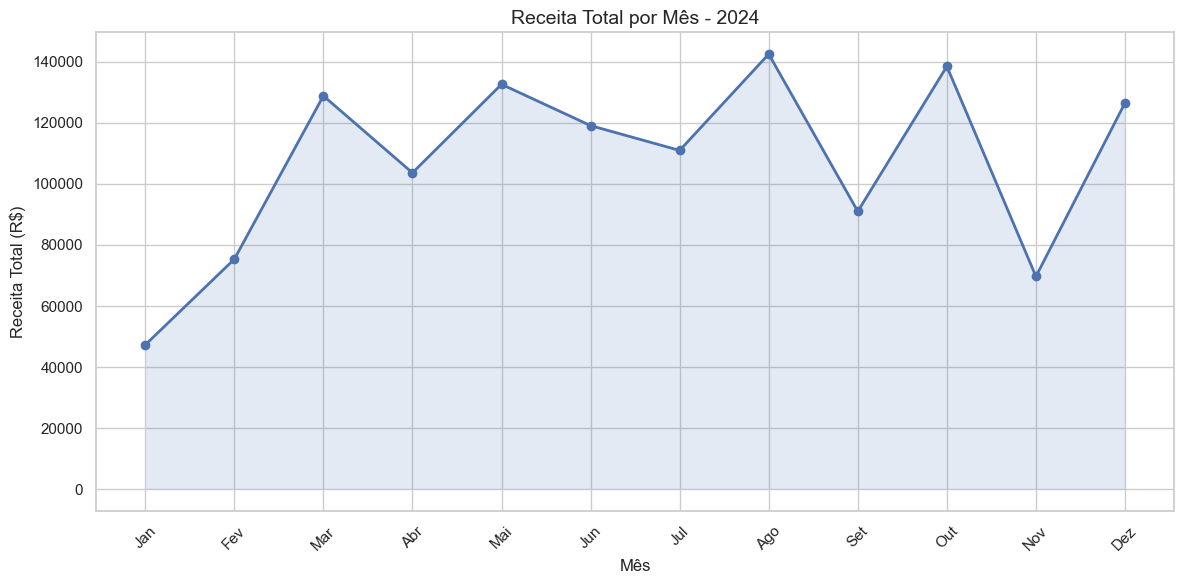

Gráfico exportado: outputs/graficos\vendas_por_mes.png


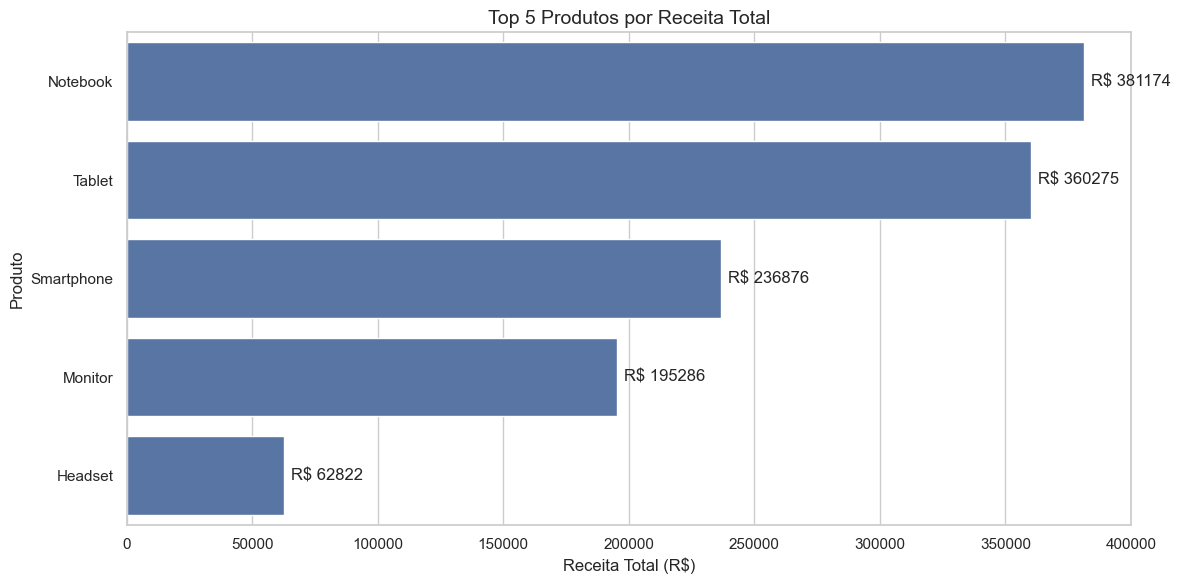

Gráfico exportado: outputs/graficos\top_produtos.png


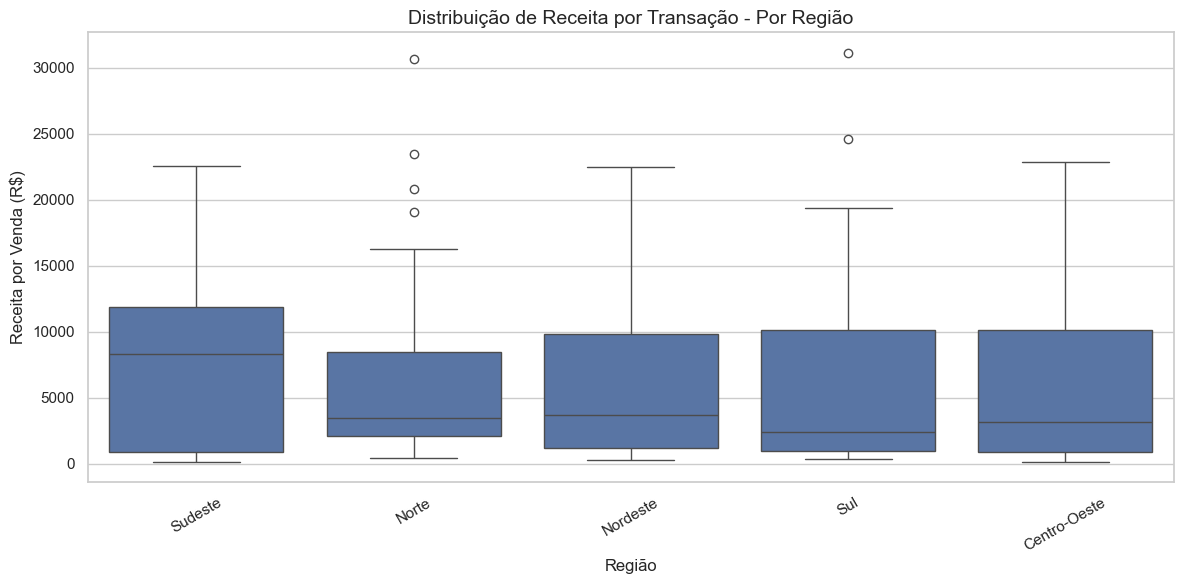

Gráfico exportado: outputs/graficos\distribuicao_regioes.png

=== VISUALIZAÇÕES GERADAS COM SUCESSO ===


In [26]:
gerar_visualizacoes(df_limpo, metricas)

Passo 18.1 Graficos complementares

In [27]:
def gerar_graficos_complementares(df, output_dir="outputs/graficos"):
    """
    Gera gráficos complementares para análise de vendas.

    Gráficos gerados:
    1. Participação das categorias no volume total vendido.
    2. Ranking de produtos por volume total vendido.
    3. Variação percentual de preço por produto.
    4. Média de peças vendidas por venda em cada dia da semana.
    5. Ticket médio por venda em cada dia da semana.
    """

    os.makedirs(output_dir, exist_ok=True)

    df_graficos = df.copy()

    # ============================================================
    # PREPARAÇÃO DA BASE
    # ============================================================

    df_graficos["data_venda_temp"] = pd.to_datetime(
        df_graficos["data_venda"],
        errors="coerce",
        dayfirst=True
    )

    df_graficos["quantidade"] = pd.to_numeric(
        df_graficos["quantidade"],
        errors="coerce"
    )

    df_graficos["preco_unitario"] = pd.to_numeric(
        df_graficos["preco_unitario"],
        errors="coerce"
    )

    if "receita_total" not in df_graficos.columns:
        df_graficos["receita_total"] = (
            df_graficos["quantidade"] * df_graficos["preco_unitario"]
        )
    else:
        df_graficos["receita_total"] = pd.to_numeric(
            df_graficos["receita_total"],
            errors="coerce"
        )

    df_graficos = df_graficos.dropna(
        subset=["data_venda_temp", "quantidade", "receita_total"]
    )

    def formatar_moeda_br(valor):
        return (
            f"R$ {valor:,.2f}"
            .replace(",", "X")
            .replace(".", ",")
            .replace("X", ".")
        )

    # ============================================================
    # 1. Gráfico de pizza: Categoria x Volume Total
    # ============================================================

    volume_por_categoria = (
        df_graficos
        .groupby("categoria")["quantidade"]
        .sum()
        .reset_index()
        .sort_values("quantidade", ascending=False)
    )

    plt.figure(figsize=(8, 8))

    plt.pie(
        volume_por_categoria["quantidade"],
        labels=volume_por_categoria["categoria"],
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title("Participação das Categorias no Volume Total Vendido")
    plt.tight_layout()

    caminho_pizza = os.path.join(
        output_dir,
        "pizza_categoria_volume_total.png"
    )

    plt.savefig(caminho_pizza, dpi=150)
    plt.show()

    print(f"Gráfico exportado: {caminho_pizza}")

    # ============================================================
    # 2. Gráfico de barras: Ranking de Produtos x Volume Total
    # ============================================================

    rank_produtos_volume = (
        df_graficos
        .groupby("produto")["quantidade"]
        .sum()
        .reset_index()
        .sort_values("quantidade", ascending=False)
    )

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=rank_produtos_volume,
        x="quantidade",
        y="produto"
    )

    plt.title("Ranking de Produtos por Volume Total Vendido")
    plt.xlabel("Volume Total Vendido em Peças")
    plt.ylabel("Produto")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f peças", padding=5)

    plt.tight_layout()

    caminho_barra = os.path.join(
        output_dir,
        "ranking_produtos_volume_total.png"
    )

    plt.savefig(caminho_barra, dpi=150)
    plt.show()

    print(f"Gráfico exportado: {caminho_barra}")

    # ============================================================
    # 3. Gráfico de variação percentual de preço por produto
    # ============================================================

    variacao_preco_produto = (
        df_graficos
        .groupby("produto")
        .agg(
            preco_minimo=("preco_unitario", "min"),
            preco_medio=("preco_unitario", "mean"),
            preco_maximo=("preco_unitario", "max")
        )
        .reset_index()
    )

    variacao_preco_produto["variacao_percentual"] = (
        (
            variacao_preco_produto["preco_maximo"]
            - variacao_preco_produto["preco_minimo"]
        )
        / variacao_preco_produto["preco_medio"]
        * 100
    ).round(2)

    variacao_preco_produto = variacao_preco_produto.sort_values(
        "variacao_percentual",
        ascending=False
    )

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        data=variacao_preco_produto,
        x="variacao_percentual",
        y="produto"
    )

    plt.title("Variação Percentual de Preço por Produto")
    plt.xlabel("Variação entre Preço Mínimo e Máximo (%)")
    plt.ylabel("Produto")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", padding=5)

    plt.tight_layout()

    caminho_variacao_preco = os.path.join(
        output_dir,
        "variacao_percentual_preco_por_produto.png"
    )

    plt.savefig(caminho_variacao_preco, dpi=150)
    plt.show()

    print(f"Gráfico exportado: {caminho_variacao_preco}")

    print("\nTabela de variação percentual de preço por produto:")

    tabela_variacao_exibicao = variacao_preco_produto.copy()

    tabela_variacao_exibicao["preco_minimo"] = (
        tabela_variacao_exibicao["preco_minimo"].apply(formatar_moeda_br)
    )

    tabela_variacao_exibicao["preco_medio"] = (
        tabela_variacao_exibicao["preco_medio"].apply(formatar_moeda_br)
    )

    tabela_variacao_exibicao["preco_maximo"] = (
        tabela_variacao_exibicao["preco_maximo"].apply(formatar_moeda_br)
    )

    tabela_variacao_exibicao["variacao_percentual"] = (
        tabela_variacao_exibicao["variacao_percentual"]
        .apply(lambda valor: f"{valor:.2f}%".replace(".", ","))
    )

    display(tabela_variacao_exibicao)

    # ============================================================
    # 4. Gráfico de média de peças por venda por dia da semana
    # ============================================================

    dias_semana = {
        0: "Segunda-feira",
        1: "Terça-feira",
        2: "Quarta-feira",
        3: "Quinta-feira",
        4: "Sexta-feira",
        5: "Sábado",
        6: "Domingo"
    }

    df_graficos["dia_semana_num"] = df_graficos["data_venda_temp"].dt.dayofweek
    df_graficos["dia_semana"] = df_graficos["dia_semana_num"].map(dias_semana)

    media_pecas_por_dia_semana = (
        df_graficos
        .groupby(["dia_semana_num", "dia_semana"])
        .agg(
            media_pecas_por_venda=("quantidade", "mean"),
            numero_vendas=("quantidade", "count")
        )
        .reset_index()
        .sort_values("dia_semana_num")
    )

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=media_pecas_por_dia_semana,
        x="dia_semana",
        y="media_pecas_por_venda"
    )

    plt.title("Média de Peças Vendidas por Venda em Cada Dia da Semana")
    plt.xlabel("Dia da Semana")
    plt.ylabel("Média de Peças por Venda")
    plt.xticks(rotation=30)

    labels_media_pecas = [
        f"{valor:.2f} peças/venda"
        for valor in media_pecas_por_dia_semana["media_pecas_por_venda"]
    ]

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=labels_media_pecas,
            padding=5
        )

    plt.tight_layout()

    caminho_media_pecas_dia_semana = os.path.join(
        output_dir,
        "media_pecas_por_venda_dia_semana.png"
    )

    plt.savefig(caminho_media_pecas_dia_semana, dpi=150)
    plt.show()

    print(f"Gráfico exportado: {caminho_media_pecas_dia_semana}")

    print("\nTabela de média de peças por venda por dia da semana:")

    tabela_media_pecas = media_pecas_por_dia_semana.copy()

    tabela_media_pecas["media_pecas_por_venda"] = (
        tabela_media_pecas["media_pecas_por_venda"]
        .apply(lambda valor: f"{valor:.2f}".replace(".", ","))
    )

    display(
        tabela_media_pecas[
            [
                "dia_semana",
                "numero_vendas",
                "media_pecas_por_venda"
            ]
        ]
    )

    # ============================================================
    # 5. Gráfico de ticket médio por dia da semana
    # ============================================================

    ticket_medio_por_dia_semana = (
        df_graficos
        .groupby(["dia_semana_num", "dia_semana"])
        .agg(
            ticket_medio=("receita_total", "mean"),
            numero_vendas=("receita_total", "count")
        )
        .reset_index()
        .sort_values("dia_semana_num")
    )

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=ticket_medio_por_dia_semana,
        x="dia_semana",
        y="ticket_medio"
    )

    plt.title("Ticket Médio por Venda em Cada Dia da Semana")
    plt.xlabel("Dia da Semana")
    plt.ylabel("Faturamento Médio por Venda")
    plt.xticks(rotation=30)

    labels_ticket_medio = [
        formatar_moeda_br(valor)
        for valor in ticket_medio_por_dia_semana["ticket_medio"]
    ]

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=labels_ticket_medio,
            padding=5
        )

    plt.tight_layout()

    caminho_ticket_medio_dia_semana = os.path.join(
        output_dir,
        "ticket_medio_dia_semana.png"
    )

    plt.savefig(caminho_ticket_medio_dia_semana, dpi=150)
    plt.show()

    print(f"Gráfico exportado: {caminho_ticket_medio_dia_semana}")

    print("\nTabela de ticket médio por dia da semana:")

    tabela_ticket_medio = ticket_medio_por_dia_semana.copy()

    tabela_ticket_medio["ticket_medio"] = (
        tabela_ticket_medio["ticket_medio"].apply(formatar_moeda_br)
    )

    display(
        tabela_ticket_medio[
            [
                "dia_semana",
                "numero_vendas",
                "ticket_medio"
            ]
        ]
    )

    print("\n=== GRÁFICOS COMPLEMENTARES GERADOS COM SUCESSO ===")

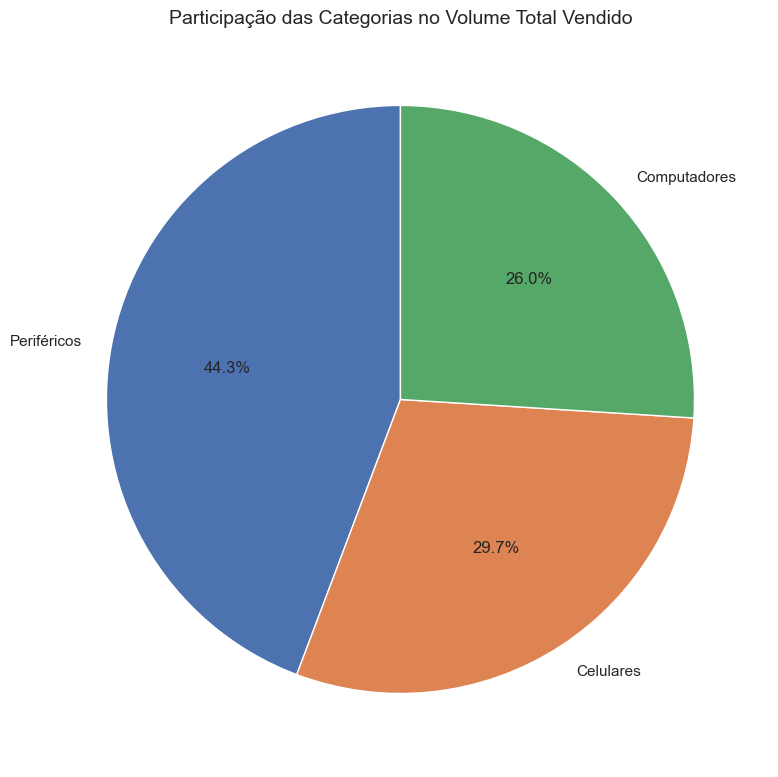

Gráfico exportado: outputs/graficos\pizza_categoria_volume_total.png


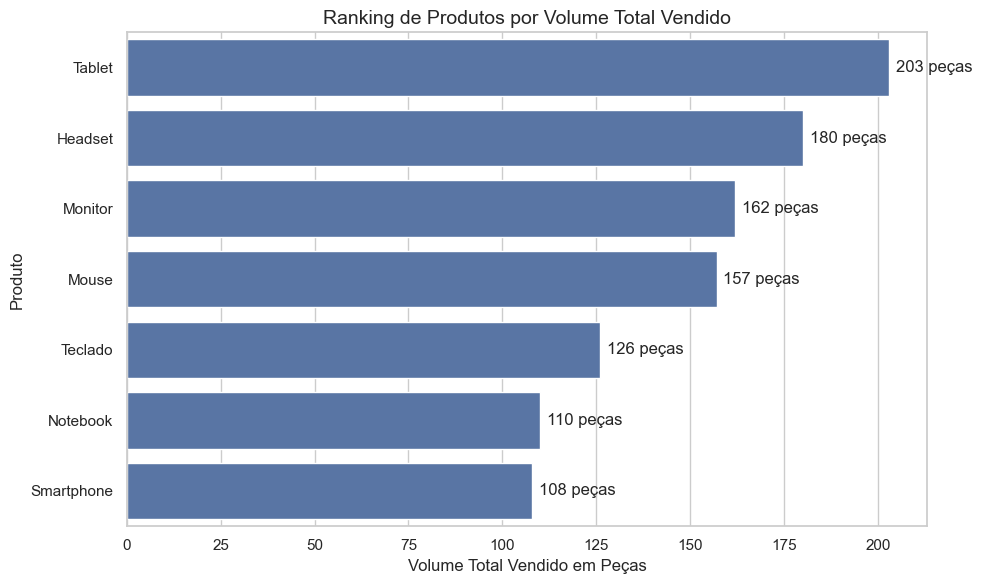

Gráfico exportado: outputs/graficos\ranking_produtos_volume_total.png


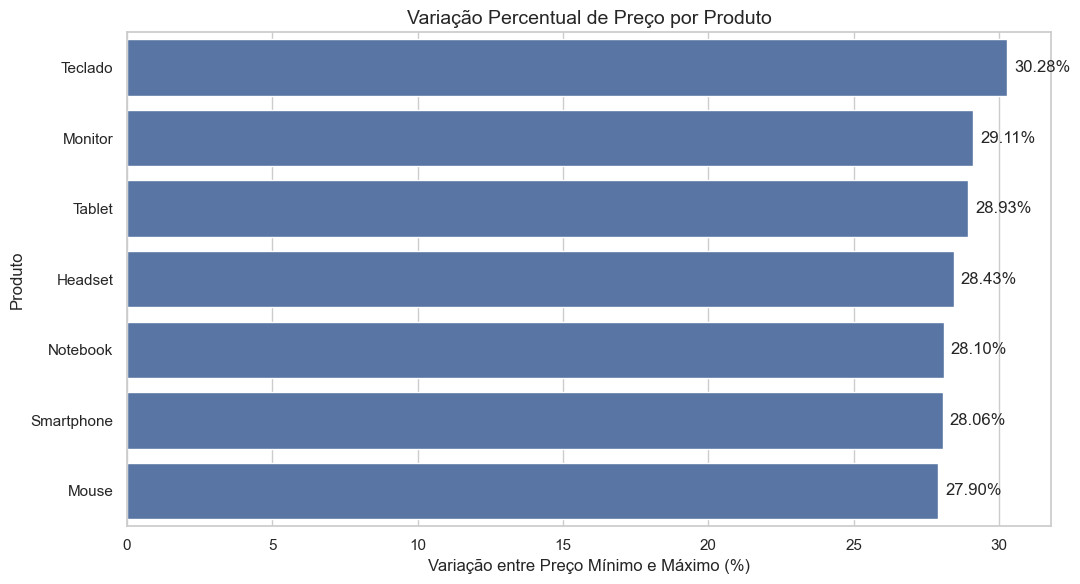

Gráfico exportado: outputs/graficos\variacao_percentual_preco_por_produto.png

Tabela de variação percentual de preço por produto:


,produto,preco_minimo,preco_medio,preco_maximo,variacao_percentual
6,Teclado,"R$ 213,87","R$ 242,19","R$ 287,21","30,28%"
1,Monitor,"R$ 1.022,12","R$ 1.204,98","R$ 1.372,89","29,11%"
5,Tablet,"R$ 1.534,42","R$ 1.791,12","R$ 2.052,56","28,93%"
0,Headset,"R$ 301,27","R$ 346,71","R$ 399,83","28,43%"
3,Notebook,"R$ 2.996,90","R$ 3.467,02","R$ 3.970,97","28,10%"
4,Smartphone,"R$ 1.899,30","R$ 2.167,12","R$ 2.507,29","28,06%"
2,Mouse,"R$ 102,90","R$ 121,82","R$ 136,89","27,90%"


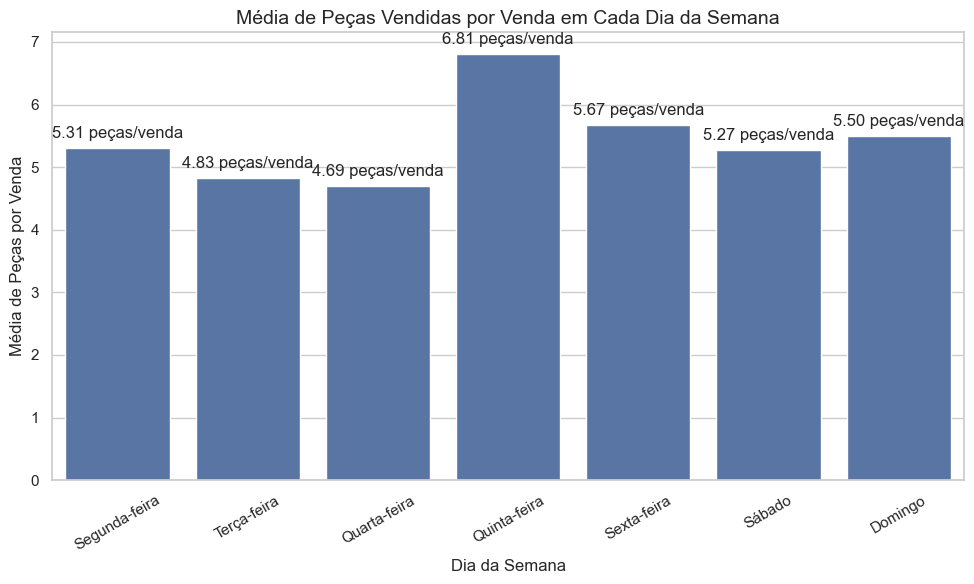

Gráfico exportado: outputs/graficos\media_pecas_por_venda_dia_semana.png

Tabela de média de peças por venda por dia da semana:


,dia_semana,numero_vendas,media_pecas_por_venda
0,Segunda-feira,29,"5,31"
1,Terça-feira,23,"4,83"
2,Quarta-feira,36,"4,69"
3,Quinta-feira,16,"6,81"
4,Sexta-feira,27,"5,67"
5,Sábado,33,"5,27"
6,Domingo,32,"5,50"


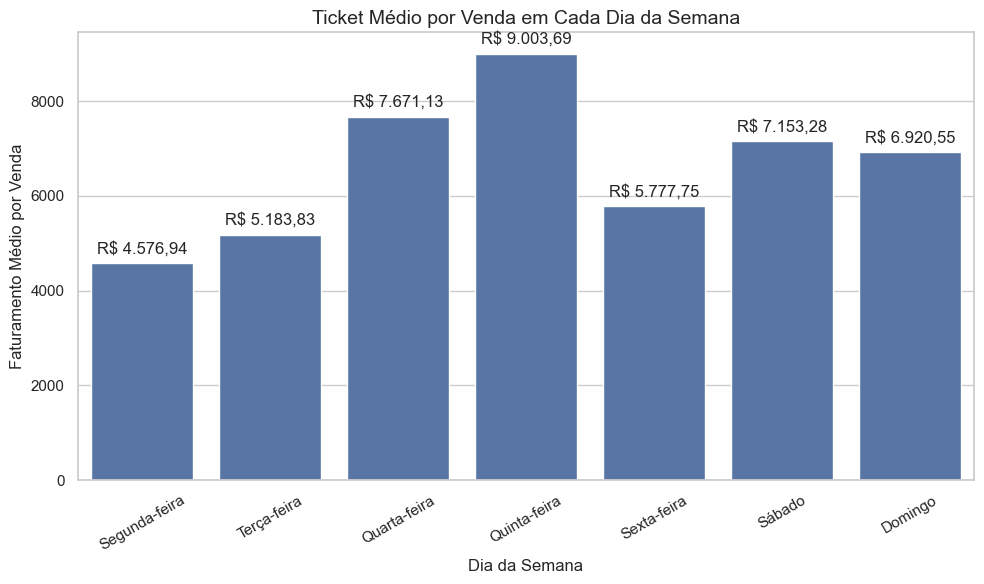

Gráfico exportado: outputs/graficos\ticket_medio_dia_semana.png

Tabela de ticket médio por dia da semana:


,dia_semana,numero_vendas,ticket_medio
0,Segunda-feira,29,"R$ 4.576,94"
1,Terça-feira,23,"R$ 5.183,83"
2,Quarta-feira,36,"R$ 7.671,13"
3,Quinta-feira,16,"R$ 9.003,69"
4,Sexta-feira,27,"R$ 5.777,75"
5,Sábado,33,"R$ 7.153,28"
6,Domingo,32,"R$ 6.920,55"



=== GRÁFICOS COMPLEMENTARES GERADOS COM SUCESSO ===


In [28]:
gerar_graficos_complementares(df_limpo)

Passo 18.2 - Grafico complementar Ranking de Clientes mensal

RELATÓRIO - TOP 3 CLIENTES POR MÊS


mes_ano,posicao,cliente,valor_comprado
janeiro/2024,🏆 1º,Cliente_032,"R$ 15.019,20"
janeiro/2024,2º,Cliente_011,"R$ 11.259,06"
janeiro/2024,3º,Cliente_022,"R$ 8.316,91"
fevereiro/2024,🏆 1º,Cliente_024,"R$ 15.591,77"
fevereiro/2024,2º,Cliente_035,"R$ 15.066,27"
fevereiro/2024,3º,Cliente_015,"R$ 12.544,17"
março/2024,🏆 1º,Cliente_046,"R$ 22.217,52"
março/2024,2º,Cliente_002,"R$ 20.034,63"
março/2024,3º,Cliente_023,"R$ 16.150,96"
abril/2024,🏆 1º,Cliente_016,"R$ 24.570,08"


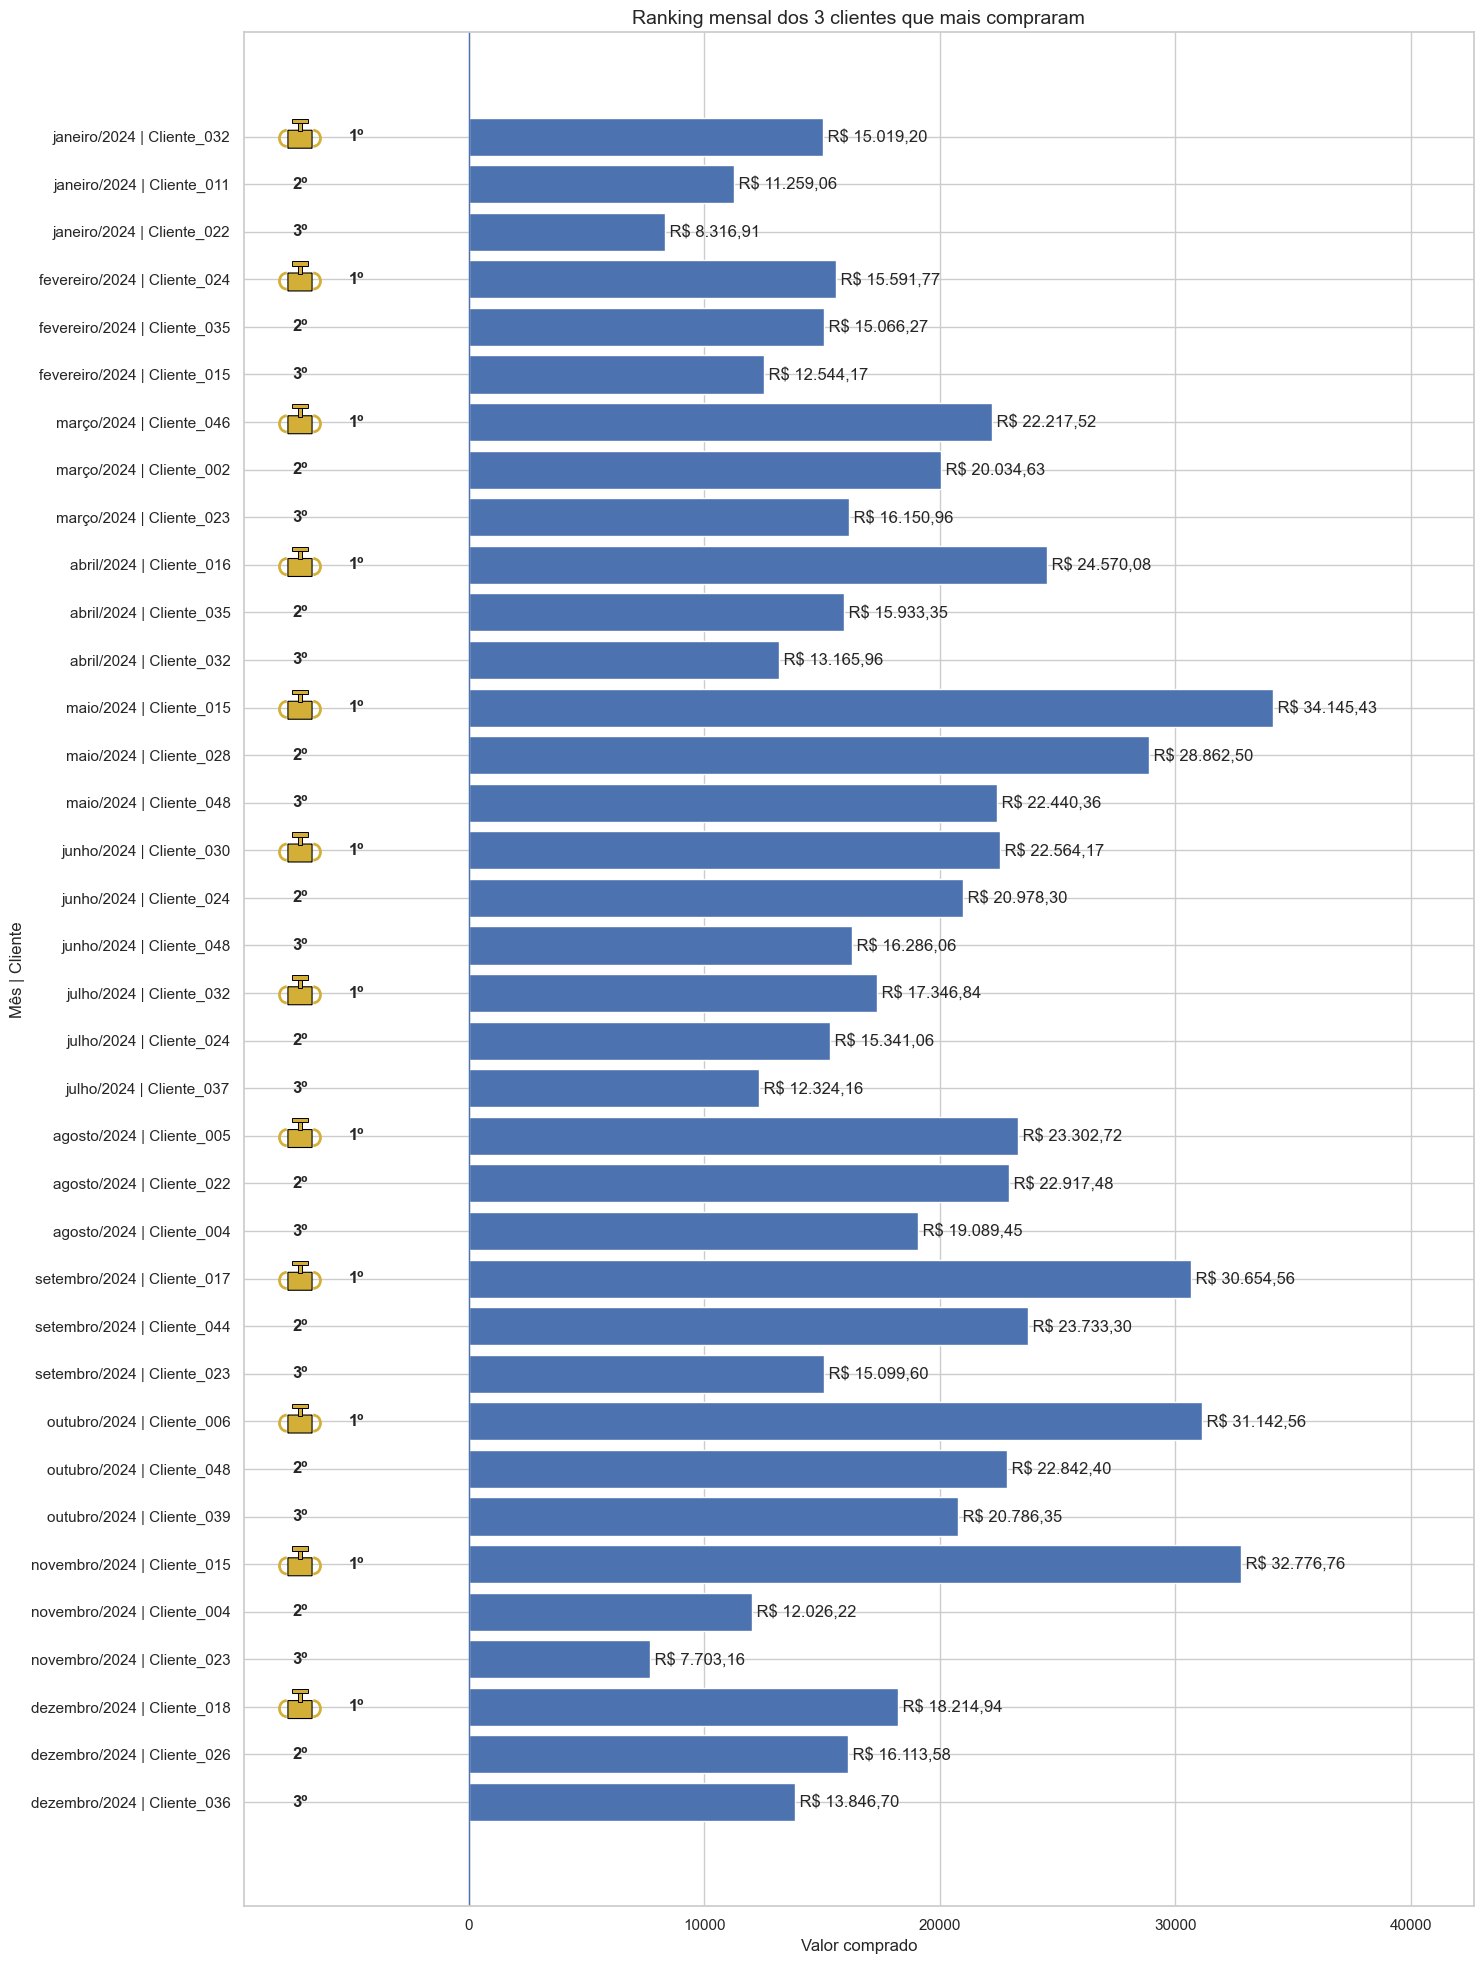

RELATÓRIO - TOP 3 CLIENTES DO ANO DE 2024


ano,posicao,cliente,valor_comprado
2024,🏆 1º,Cliente_015,"R$ 82.964,76"
2024,2º,Cliente_035,"R$ 75.402,52"
2024,3º,Cliente_048,"R$ 64.324,93"


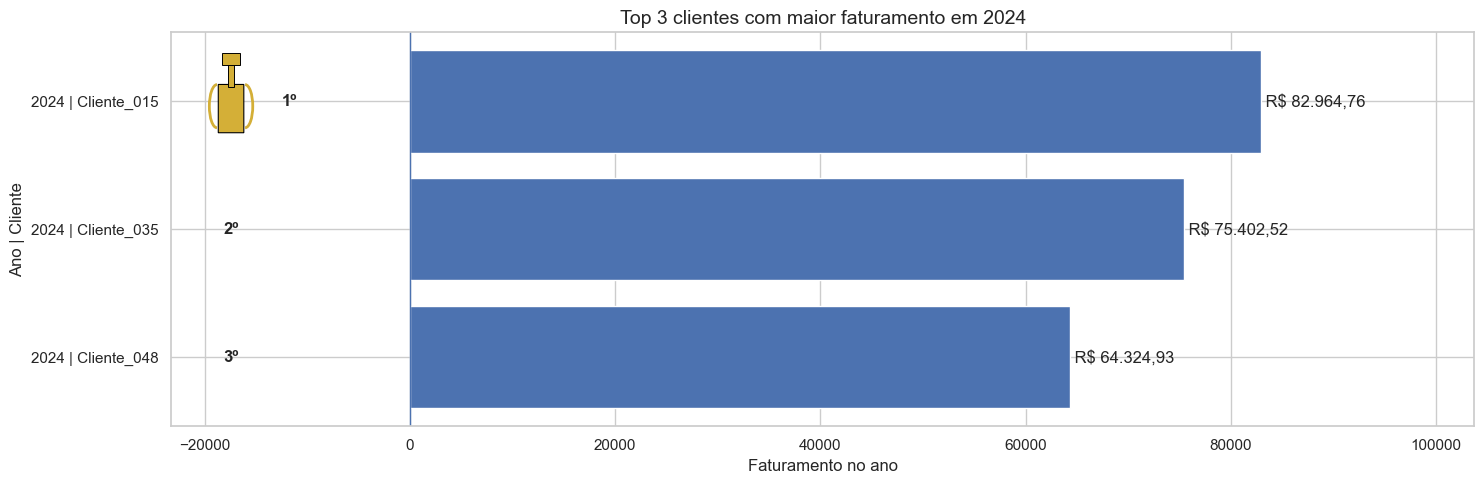

Relatório mensal CSV exportado para:
C:\Users\renat\OneDrive\Documentos\SENAI\MINIPROJETO\salesinsight-py\outputs\relatorio_top3_clientes_por_mes.csv

Gráfico mensal PNG exportado para:
C:\Users\renat\OneDrive\Documentos\SENAI\MINIPROJETO\salesinsight-py\outputs\graficos\grafico_top3_clientes_por_mes.png

Relatório anual CSV exportado para:
C:\Users\renat\OneDrive\Documentos\SENAI\MINIPROJETO\salesinsight-py\outputs\relatorio_top3_clientes_ano_2024.csv

Gráfico anual PNG exportado para:
C:\Users\renat\OneDrive\Documentos\SENAI\MINIPROJETO\salesinsight-py\outputs\graficos\grafico_top3_clientes_ano_2024.png


In [29]:
# ============================================================
# FUNÇÃO: TOP 3 CLIENTES POR MÊS + TOP 3 CLIENTES DO ANO
# Exporta:
# - Relatórios CSV direto em outputs/
# - Gráficos PNG em outputs/graficos/
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from IPython.display import display, HTML


def gerar_rankings_clientes(dados, pasta_outputs="outputs", ano_referencia=2024):
    """
    Gera:
    1. Ranking mensal dos 3 clientes que mais compraram em cada mês.
    2. Ranking anual dos 3 clientes que mais compraram no ano informado.

    Arquivos gerados:
    - outputs/relatorio_top3_clientes_por_mes.csv
    - outputs/relatorio_top3_clientes_ano_2024.csv
    - outputs/graficos/grafico_top3_clientes_por_mes.png
    - outputs/graficos/grafico_top3_clientes_ano_2024.png
    """

    plt.close("all")

    # ========================================================
    # PASTAS DE SAÍDA
    # ========================================================

    PASTA_OUTPUTS = Path(pasta_outputs)
    PASTA_GRAFICOS = PASTA_OUTPUTS / "graficos"

    PASTA_OUTPUTS.mkdir(exist_ok=True)
    PASTA_GRAFICOS.mkdir(parents=True, exist_ok=True)

    # ========================================================
    # FUNÇÕES AUXILIARES
    # ========================================================

    def formatar_moeda(valor):
        return (
            f"R$ {valor:,.2f}"
            .replace(",", "X")
            .replace(".", ",")
            .replace("X", ".")
        )

    def desenhar_trofeu(ax, x, y, sx, sy):
        """
        Desenha um troféu diretamente no gráfico.
        Não depende de emoji.
        """

        copa = patches.FancyBboxPatch(
            (x - sx * 0.50, y - sy * 0.15),
            sx,
            sy * 0.45,
            boxstyle="round,pad=0.02",
            facecolor="#D4AF37",
            edgecolor="black",
            linewidth=0.8,
            clip_on=False,
            zorder=5
        )

        alca_esquerda = patches.Arc(
            (x - sx * 0.55, y + sy * 0.05),
            sx * 0.60,
            sy * 0.45,
            theta1=90,
            theta2=270,
            edgecolor="#D4AF37",
            linewidth=2,
            clip_on=False,
            zorder=5
        )

        alca_direita = patches.Arc(
            (x + sx * 0.55, y + sy * 0.05),
            sx * 0.60,
            sy * 0.45,
            theta1=-90,
            theta2=90,
            edgecolor="#D4AF37",
            linewidth=2,
            clip_on=False,
            zorder=5
        )

        haste = patches.Rectangle(
            (x - sx * 0.10, y - sy * 0.40),
            sx * 0.20,
            sy * 0.25,
            facecolor="#D4AF37",
            edgecolor="black",
            linewidth=0.7,
            clip_on=False,
            zorder=5
        )

        base = patches.Rectangle(
            (x - sx * 0.35, y - sy * 0.50),
            sx * 0.70,
            sy * 0.12,
            facecolor="#D4AF37",
            edgecolor="black",
            linewidth=0.7,
            clip_on=False,
            zorder=5
        )

        ax.add_patch(alca_esquerda)
        ax.add_patch(alca_direita)
        ax.add_patch(copa)
        ax.add_patch(haste)
        ax.add_patch(base)

    def exibir_tabela_sem_indice(df_tabela):
        display(
            HTML(
                df_tabela.to_html(
                    index=False,
                    escape=False
                )
            )
        )

    def gerar_grafico_horizontal(
        df_grafico,
        coluna_rotulo,
        coluna_valor,
        coluna_ranking,
        titulo,
        xlabel,
        ylabel,
        arquivo_saida
    ):
        """
        Gera gráfico horizontal com:
        - posição no ranking
        - troféu desenhado no 1º lugar
        - valor formatado em reais
        """

        fig, ax = plt.subplots(
            figsize=(15, max(5, len(df_grafico) * 0.55))
        )

        posicoes_y = range(len(df_grafico))

        ax.barh(
            posicoes_y,
            df_grafico[coluna_valor]
        )

        ax.set_yticks(posicoes_y)
        ax.set_yticklabels(df_grafico[coluna_rotulo])

        ax.invert_yaxis()

        ax.set_title(titulo)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        maior_valor = df_grafico[coluna_valor].max()

        if pd.isna(maior_valor) or maior_valor == 0:
            maior_valor = 1

        ax.set_xlim(-maior_valor * 0.28, maior_valor * 1.25)
        ax.axvline(0, linewidth=1)

        x_trofeu = -maior_valor * 0.21
        x_posicao = -maior_valor * 0.15

        for indice, linha in enumerate(df_grafico.itertuples()):
            valor = getattr(linha, coluna_valor)
            ranking = getattr(linha, coluna_ranking)

            if ranking == 1:
                desenhar_trofeu(
                    ax=ax,
                    x=x_trofeu,
                    y=indice,
                    sx=maior_valor * 0.030,
                    sy=0.75
                )

                ax.text(
                    x_posicao,
                    indice,
                    "1º",
                    va="center",
                    ha="left",
                    fontweight="bold"
                )

            else:
                ax.text(
                    x_trofeu,
                    indice,
                    f"{ranking}º",
                    va="center",
                    ha="center",
                    fontweight="bold"
                )

            ax.text(
                valor,
                indice,
                f" {formatar_moeda(valor)}",
                va="center"
            )

        plt.tight_layout()

        plt.savefig(
            arquivo_saida,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    # ========================================================
    # CÓPIA E TRATAMENTO DA BASE
    # ========================================================

    dados_ranking = dados.copy()

    dados_ranking["data_venda"] = pd.to_datetime(
        dados_ranking["data_venda"],
        errors="coerce",
        dayfirst=True
    )

    dados_ranking["quantidade"] = pd.to_numeric(
        dados_ranking["quantidade"],
        errors="coerce"
    )

    dados_ranking["preco_unitario"] = pd.to_numeric(
        dados_ranking["preco_unitario"],
        errors="coerce"
    )

    if "total_venda" not in dados_ranking.columns:
        dados_ranking["total_venda"] = (
            dados_ranking["quantidade"] * dados_ranking["preco_unitario"]
        )
    else:
        dados_ranking["total_venda"] = pd.to_numeric(
            dados_ranking["total_venda"],
            errors="coerce"
        )

    dados_ranking = dados_ranking.dropna(
        subset=["data_venda", "cliente", "total_venda"]
    )

    if dados_ranking.empty:
        raise ValueError("Não há dados válidos para gerar os rankings.")

    # ========================================================
    # TRATAMENTO DO MÊS
    # ========================================================

    meses_pt = {
        1: "janeiro",
        2: "fevereiro",
        3: "março",
        4: "abril",
        5: "maio",
        6: "junho",
        7: "julho",
        8: "agosto",
        9: "setembro",
        10: "outubro",
        11: "novembro",
        12: "dezembro"
    }

    dados_ranking["ano"] = dados_ranking["data_venda"].dt.year
    dados_ranking["mes_numero"] = dados_ranking["data_venda"].dt.month
    dados_ranking["mes_nome"] = dados_ranking["mes_numero"].map(meses_pt)

    dados_ranking["mes_ano"] = (
        dados_ranking["mes_nome"] + "/" + dados_ranking["ano"].astype(str)
    )

    dados_ranking["ordem_mes"] = dados_ranking["data_venda"].dt.to_period("M")

    # ========================================================
    # RANKING MENSAL
    # ========================================================

    compras_cliente_mes = (
        dados_ranking
        .groupby(["ordem_mes", "mes_ano", "cliente"], as_index=False)["total_venda"]
        .sum()
        .rename(columns={"total_venda": "valor_comprado"})
    )

    compras_cliente_mes = compras_cliente_mes.sort_values(
        ["ordem_mes", "valor_comprado"],
        ascending=[True, False]
    )

    compras_cliente_mes["ranking"] = (
        compras_cliente_mes
        .groupby("ordem_mes")
        .cumcount() + 1
    )

    top3_clientes_mes = compras_cliente_mes[
        compras_cliente_mes["ranking"] <= 3
    ].copy()

    top3_clientes_mes = top3_clientes_mes.sort_values(
        ["ordem_mes", "ranking"]
    )

    top3_clientes_mes["posicao"] = top3_clientes_mes["ranking"].map({
        1: "🏆 1º",
        2: "2º",
        3: "3º"
    })

    relatorio_top3_clientes_mes = top3_clientes_mes[
        ["mes_ano", "posicao", "cliente", "valor_comprado"]
    ].copy()

    relatorio_top3_clientes_mes["valor_comprado"] = (
        relatorio_top3_clientes_mes["valor_comprado"].round(2)
    )

    relatorio_top3_clientes_mes = (
        relatorio_top3_clientes_mes.reset_index(drop=True)
    )

    relatorio_top3_clientes_mes_exportacao = relatorio_top3_clientes_mes.copy()

    relatorio_top3_clientes_mes_exportacao["valor_comprado"] = (
        relatorio_top3_clientes_mes_exportacao["valor_comprado"].apply(formatar_moeda)
    )

    print("RELATÓRIO - TOP 3 CLIENTES POR MÊS")
    exibir_tabela_sem_indice(relatorio_top3_clientes_mes_exportacao)

    arquivo_csv_mes = PASTA_OUTPUTS / "relatorio_top3_clientes_por_mes.csv"

    relatorio_top3_clientes_mes_exportacao.to_csv(
        arquivo_csv_mes,
        index=False,
        encoding="utf-8-sig"
    )

    top3_grafico_mes = top3_clientes_mes.copy()

    top3_grafico_mes["rotulo_grafico"] = (
        top3_grafico_mes["mes_ano"]
        + " | "
        + top3_grafico_mes["cliente"]
    )

    arquivo_grafico_mes = PASTA_GRAFICOS / "grafico_top3_clientes_por_mes.png"

    gerar_grafico_horizontal(
        df_grafico=top3_grafico_mes,
        coluna_rotulo="rotulo_grafico",
        coluna_valor="valor_comprado",
        coluna_ranking="ranking",
        titulo="Ranking mensal dos 3 clientes que mais compraram",
        xlabel="Valor comprado",
        ylabel="Mês | Cliente",
        arquivo_saida=arquivo_grafico_mes
    )

    # ========================================================
    # RANKING ANUAL - TOP 3 CLIENTES DO ANO DE 2024
    # ========================================================

    dados_ano = dados_ranking[
        dados_ranking["ano"] == ano_referencia
    ].copy()

    if dados_ano.empty:
        raise ValueError(f"Não há dados válidos para o ano {ano_referencia}.")

    compras_cliente_ano = (
        dados_ano
        .groupby(["ano", "cliente"], as_index=False)["total_venda"]
        .sum()
        .rename(columns={"total_venda": "valor_comprado"})
    )

    compras_cliente_ano = compras_cliente_ano.sort_values(
        "valor_comprado",
        ascending=False
    )

    compras_cliente_ano["ranking"] = range(1, len(compras_cliente_ano) + 1)

    top3_clientes_ano = compras_cliente_ano[
        compras_cliente_ano["ranking"] <= 3
    ].copy()

    top3_clientes_ano["posicao"] = top3_clientes_ano["ranking"].map({
        1: "🏆 1º",
        2: "2º",
        3: "3º"
    })

    relatorio_top3_clientes_ano = top3_clientes_ano[
        ["ano", "posicao", "cliente", "valor_comprado"]
    ].copy()

    relatorio_top3_clientes_ano["valor_comprado"] = (
        relatorio_top3_clientes_ano["valor_comprado"].round(2)
    )

    relatorio_top3_clientes_ano = (
        relatorio_top3_clientes_ano.reset_index(drop=True)
    )

    relatorio_top3_clientes_ano_exportacao = relatorio_top3_clientes_ano.copy()

    relatorio_top3_clientes_ano_exportacao["valor_comprado"] = (
        relatorio_top3_clientes_ano_exportacao["valor_comprado"].apply(formatar_moeda)
    )

    print(f"RELATÓRIO - TOP 3 CLIENTES DO ANO DE {ano_referencia}")
    exibir_tabela_sem_indice(relatorio_top3_clientes_ano_exportacao)

    arquivo_csv_ano = (
        PASTA_OUTPUTS / f"relatorio_top3_clientes_ano_{ano_referencia}.csv"
    )

    relatorio_top3_clientes_ano_exportacao.to_csv(
        arquivo_csv_ano,
        index=False,
        encoding="utf-8-sig"
    )

    top3_grafico_ano = top3_clientes_ano.copy()

    top3_grafico_ano["rotulo_grafico"] = (
        top3_grafico_ano["ano"].astype(str)
        + " | "
        + top3_grafico_ano["cliente"]
    )

    arquivo_grafico_ano = (
        PASTA_GRAFICOS / f"grafico_top3_clientes_ano_{ano_referencia}.png"
    )

    gerar_grafico_horizontal(
        df_grafico=top3_grafico_ano,
        coluna_rotulo="rotulo_grafico",
        coluna_valor="valor_comprado",
        coluna_ranking="ranking",
        titulo=f"Top 3 clientes com maior faturamento em {ano_referencia}",
        xlabel="Faturamento no ano",
        ylabel="Ano | Cliente",
        arquivo_saida=arquivo_grafico_ano
    )

    # ========================================================
    # CONFIRMAÇÃO
    # ========================================================

    print("Relatório mensal CSV exportado para:")
    print(arquivo_csv_mes.resolve())

    print("\nGráfico mensal PNG exportado para:")
    print(arquivo_grafico_mes.resolve())

    print("\nRelatório anual CSV exportado para:")
    print(arquivo_csv_ano.resolve())

    print("\nGráfico anual PNG exportado para:")
    print(arquivo_grafico_ano.resolve())

    return {
        "relatorio_top3_clientes_mes": relatorio_top3_clientes_mes_exportacao,
        "relatorio_top3_clientes_ano": relatorio_top3_clientes_ano_exportacao
    }


# ============================================================
# EXECUÇÃO DA FUNÇÃO
# ============================================================

try:
    resultados_rankings_clientes = gerar_rankings_clientes(
        df_limpo,
        ano_referencia=2024
    )
except NameError:
    resultados_rankings_clientes = gerar_rankings_clientes(
        df,
        ano_referencia=2024
    )

relatorio_top3_clientes_mes = resultados_rankings_clientes["relatorio_top3_clientes_mes"]
relatorio_top3_clientes_ano = resultados_rankings_clientes["relatorio_top3_clientes_ano"]

Passo 19 - Criar uma Classe para o Pipeline

In [30]:
class AnalisadorDeVendas:
    """
    Classe responsável por encapsular o pipeline de análise de vendas.
    Mantém o estado do DataFrame e os resultados intermediários.
    """

    def __init__(self, caminho_arquivo):
        self.caminho_arquivo = caminho_arquivo
        self.df_bruto = None
        self.df_limpo = None
        self.metricas = {}
        self.clientes = None
        self.relatorio_limpeza = {}
        self.stats_numpy = None

    def carregar(self):
        self.df_bruto = pd.read_csv(self.caminho_arquivo)

        print(f"[AnalisadorDeVendas] Arquivo carregado: {self.caminho_arquivo}")
        print(f"Registros carregados: {len(self.df_bruto)}")

        return self

    def usar_df_limpo(self, df_limpo):
        """
        Usa diretamente um DataFrame já limpo e transformado.
        Evita reler o CSV e refazer as etapas de limpeza e transformação.
        """

        self.df_limpo = df_limpo.copy()

        self.relatorio_limpeza = {
            "registros_iniciais": "DataFrame já tratado",
            "registros_finais": len(self.df_limpo)
        }

        print("[AnalisadorDeVendas] df_limpo carregado diretamente.")
        print(f"Registros recebidos: {len(self.df_limpo)}")

        return self

    def limpar(self):
        self.df_limpo, self.relatorio_limpeza = limpar_dados(self.df_bruto.copy())
        return self

    def transformar(self):
        self.df_limpo = criar_colunas_derivadas(self.df_limpo)
        return self

    def analisar(self):
        self.metricas = calcular_metricas(self.df_limpo)
        self.clientes = segmentar_clientes(self.df_limpo)
        self.stats_numpy = calcular_estatisticas_numpy(self.df_limpo)

        return self

    def visualizar(self):
        gerar_visualizacoes(self.df_limpo, self.metricas)
        return self

    def exportar_relatorio(self, caminho="outputs/relatorio_resumo.csv"):
        os.makedirs("outputs", exist_ok=True)

        self.metricas["por_mes"].to_csv(caminho, index=False, encoding="utf-8-sig")

        print(f"\n[AnalisadorDeVendas] Relatório exportado: {caminho}")

        return self

    def resumo(self):
        print("\n" + "=" * 50)
        print("RESUMO EXECUTIVO - SALESINSIGHT PY")
        print("=" * 50)

        print(f"Arquivo analisado: {self.caminho_arquivo}")
        print(f"Registros brutos: {self.relatorio_limpeza.get('registros_iniciais', 'N/A')}")
        print(f"Registros limpos: {self.relatorio_limpeza.get('registros_finais', 'N/A')}")

        receita = self.df_limpo["receita_total"].sum() if self.df_limpo is not None else 0

        receita_formatada = (
            f"R$ {receita:,.2f}"
            .replace(",", "X")
            .replace(".", ",")
            .replace("X", ".")
        )

        print(f"Receita total anual: {receita_formatada}")

        if self.clientes is not None:
            top = self.clientes.iloc[0]

            total_gasto_formatado = (
                f"R$ {top['total_gasto']:,.2f}"
                .replace(",", "X")
                .replace(".", ",")
                .replace("X", ".")
            )

            print(f"Cliente top: {top['cliente']} - {total_gasto_formatado}")

        print("=" * 50)

In [31]:
analisador = AnalisadorDeVendas("vendas.csv")

(
    analisador
    .usar_df_limpo(df_limpo)
    .analisar()
    .resumo()
)

[AnalisadorDeVendas] df_limpo carregado diretamente.
Registros recebidos: 196

=== POR MES ===


,mes,receita_total,quantidade,n_vendas
0,1,47301.20,46,10
1,2,75342.20,94,16
2,3,128796.85,92,19
3,4,103611.52,75,15
4,5,132570.78,100,17
5,6,119059.73,76,16
6,7,110935.66,99,19
7,8,142461.63,83,15
8,9,90992.72,66,11
9,10,138446.52,127,21



=== TOP PRODUTOS ===


,produto,receita_total
0,Notebook,381173.55
1,Tablet,360275.04
2,Smartphone,236876.48
3,Monitor,195286.34
4,Headset,62822.19



=== POR CATEGORIA ===


...


=== POR TRIMESTRE ===


,trimestre,receita_total,media_ticket
1,T2,355242.03,7400.875625
2,T3,344390.01,7653.111333
3,T4,334622.03,5769.345345
0,T1,251440.25,5587.561111



=== SEGMENTAÇÃO DE CLIENTES ===


,cliente,total_gasto,quantidade_pecas_compradas,quantidade_de_compras,segmento
13,Cliente_015,82964.76,52,8,Ouro
33,Cliente_035,75402.52,44,7,Ouro
46,Cliente_048,64324.93,33,7,Ouro
22,Cliente_024,57381.21,56,8,Ouro
5,Cliente_006,50249.74,43,6,Ouro
3,Cliente_004,50106.56,25,5,Ouro
21,Cliente_023,46863.73,26,6,Ouro
28,Cliente_030,45659.41,26,5,Ouro
30,Cliente_032,45532.00,26,4,Ouro
42,Cliente_044,43513.88,36,6,Ouro



Distribuição de segmentos:
segmento
Ouro      32
Prata      9
Bronze     8
Name: count, dtype: int64

=== ESTATÍSTICAS COM NUMPY ===
Receita média por venda: R$ 6559.66
Receita mediana por venda: R$ 3591.18
Desvio padrão: R$ 6625.37
Receita total: R$ 1285694.32
Percentil 25: R$ 1096.07
Percentil 75: R$ 10657.42

Receitas normalizadas — primeiros 5 valores:
[0.0024 0.0443 0.1512 0.3184 0.027 ]

Vendas acima da média: 78 de 196

RESUMO EXECUTIVO - SALESINSIGHT PY
Arquivo analisado: vendas.csv
Registros brutos: DataFrame já tratado
Registros limpos: 196
Receita total anual: R$ 1.285.694,32
Cliente top: Cliente_015 - R$ 82.964,76


Passo 20 - Criar Analisador De Vendas com funcionalidades de projeção simples

In [32]:
# ============================================================
# CLASSE FILHA: ANALISADOR COM PROJEÇÃO
# RF10 - Uso de Herança
# ============================================================

import numpy as np
import pandas as pd


class AnalisadorComProjecao(AnalisadorDeVendas):

    def __init__(self, caminho_arquivo, meses_projecao=3):
        super().__init__(caminho_arquivo)
        self.meses_projecao = meses_projecao
        self.projecoes = []

    def projetar_tendencia(self):

        if not hasattr(self, "metricas") or not self.metricas:
            print("[AVISO] Rode .analisar() antes de projetar.")
            return self

        if "por_mes" not in self.metricas:
            print("[AVISO] Métrica 'por_mes' não encontrada. Rode .analisar() novamente.")
            return self

        por_mes = self.metricas["por_mes"].copy()

        if por_mes.empty:
            print("[AVISO] Não há dados mensais suficientes para projetar.")
            return self

        if "mes" not in por_mes.columns or "receita_total" not in por_mes.columns:
            print("[AVISO] A métrica 'por_mes' precisa conter as colunas 'mes' e 'receita_total'.")
            return self

        meses_pt = {
            1: "Janeiro",
            2: "Fevereiro",
            3: "Março",
            4: "Abril",
            5: "Maio",
            6: "Junho",
            7: "Julho",
            8: "Agosto",
            9: "Setembro",
            10: "Outubro",
            11: "Novembro",
            12: "Dezembro"
        }

        def formatar_moeda_br(valor):
            return (
                f"R$ {valor:,.2f}"
                .replace(",", "X")
                .replace(".", ",")
                .replace("X", ".")
            )

        def converter_valor_financeiro(valor):
            if pd.isna(valor):
                return np.nan

            if isinstance(valor, (int, float)):
                return float(valor)

            texto = str(valor).strip()

            texto = texto.replace("R$", "")
            texto = texto.replace(" ", "")

            if "," in texto:
                texto = texto.replace(".", "")
                texto = texto.replace(",", ".")

            try:
                return float(texto)
            except ValueError:
                return np.nan

        por_mes["mes"] = pd.to_numeric(
            por_mes["mes"],
            errors="coerce"
        )

        por_mes["receita_total"] = por_mes["receita_total"].apply(
            converter_valor_financeiro
        )

        por_mes = por_mes.dropna(
            subset=["mes", "receita_total"]
        )

        if por_mes.empty:
            print("[AVISO] Não há dados mensais válidos para projetar.")
            return self

        por_mes["mes"] = por_mes["mes"].astype(int)

        por_mes = por_mes.sort_values("mes")

        receitas_historicas = por_mes["receita_total"].to_numpy()

        if len(receitas_historicas) == 0:
            print("[AVISO] Não há receitas históricas para projetar.")
            return self

        ultimos_meses = receitas_historicas[-3:]

        media_movel = np.mean(ultimos_meses)
        tendencia = np.std(ultimos_meses) * 0.1

        ultimo_mes = int(por_mes["mes"].max())

        print("\n=== PROJEÇÃO DE TENDÊNCIA (Média Móvel Simples) ===")
        print(
            f"Base: média dos últimos {len(ultimos_meses)} mês(es) = "
            f"{formatar_moeda_br(media_movel)}"
        )

        self.projecoes = []

        for i in range(1, self.meses_projecao + 1):
            mes_projetado = (ultimo_mes + i - 1) % 12 + 1
            mes_nome = meses_pt[mes_projetado]

            receita_projetada = media_movel + (tendencia * i)

            self.projecoes.append(
                {
                    "mes": mes_projetado,
                    "mes_nome": mes_nome,
                    "receita_projetada": round(receita_projetada, 2),
                    "receita_projetada_br": formatar_moeda_br(receita_projetada)
                }
            )

            print(
                f"{mes_nome} (projeção): "
                f"{formatar_moeda_br(receita_projetada)}"
            )

        return self

    def exibir_projecao_detalhada(self):

        if not self.projecoes:
            print("[AVISO] Nenhuma projeção disponível. Rode .projetar_tendencia() primeiro.")
            return self

        print("\n=== DETALHAMENTO DAS PROJEÇÕES ===")

        for projecao in self.projecoes:
            mes_nome = projecao.get(
                "mes_nome",
                f"Mês {projecao['mes']:02d}"
            )

            receita_formatada = projecao.get(
                "receita_projetada_br",
                (
                    f"R$ {projecao['receita_projetada']:,.2f}"
                    .replace(",", "X")
                    .replace(".", ",")
                    .replace("X", ".")
                )
            )

            print(f"{mes_nome}: {receita_formatada}")

        return self

20.1 Teste da Classe com Herança

Nesta etapa, foi criada a classe `AnalisadorComProjecao`, que herda os métodos da classe `AnalisadorDeVendas` e adiciona uma funcionalidade específica de projeção de tendência.

A classe utiliza o `df_limpo` já tratado e transformado para calcular métricas mensais e projetar a receita dos próximos três meses com base na média móvel dos últimos três meses do ano.

In [33]:
# Criar o analisador usando o df_limpo já existente

analisador_teste = AnalisadorComProjecao("vendas.csv", meses_projecao=3)

# Usar diretamente o df_limpo já tratado e transformado
analisador_teste.df_limpo = df_limpo.copy()

# Calcular métricas com base no df_limpo atual
analisador_teste.metricas = calcular_metricas(analisador_teste.df_limpo)

# Exibir as colunas transformadas
colunas_transformadas = [
    "data_venda",
    "produto",
    "quantidade",
    "preco_unitario",
    "receita_total",
    "mes",
    "mes_nome",
    "trimestre",
    "ano",
    "faixa_receita_item",
    "preco_medio_item",
    "comparacao_preco_media",
    "percentual_diferenca_media"
]

display(analisador_teste.df_limpo[colunas_transformadas].head(10))

# Executar a projeção com base nas métricas do df_limpo
analisador_teste.projetar_tendencia()

# Exibir projeção detalhada
analisador_teste.exibir_projecao_detalhada()


=== POR MES ===


,mes,receita_total,quantidade,n_vendas
0,1,47301.20,46,10
1,2,75342.20,94,16
2,3,128796.85,92,19
3,4,103611.52,75,15
4,5,132570.78,100,17
5,6,119059.73,76,16
6,7,110935.66,99,19
7,8,142461.63,83,15
8,9,90992.72,66,11
9,10,138446.52,127,21



=== TOP PRODUTOS ===


,produto,receita_total
0,Notebook,381173.55
1,Tablet,360275.04
2,Smartphone,236876.48
3,Monitor,195286.34
4,Headset,62822.19



=== POR CATEGORIA ===


...

,regiao,receita_total,media_ticket
3,Sudeste,331034.10,7698.467442
2,Norte,252849.55,7023.598611
0,Centro-Oeste,248273.50,5911.273810
1,Nordeste,235677.50,5891.937500
4,Sul,217859.67,6224.562000



=== POR TRIMESTRE ===


,trimestre,receita_total,media_ticket
1,T2,355242.03,7400.875625
2,T3,344390.01,7653.111333
3,T4,334622.03,5769.345345
0,T1,251440.25,5587.561111


,data_venda,produto,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item,preco_medio_item,comparacao_preco_media,percentual_diferenca_media
0,2024-05-20,Mouse,2,102.90,205.80,5,Maio,T2,2024,Baixo Valor,121.82,Abaixo,"-15,53 %"
1,2024-02-17,Teclado,7,214.88,1504.16,2,Fevereiro,T1,2024,Médio Valor,242.19,Abaixo,"-11,28 %"
2,2024-05-22,Monitor,4,1204.98,4819.93,5,Maio,T2,2024,Médio Valor,1204.98,Na média,"0,00 %"
3,2024-06-21,Smartphone,4,2501.76,10007.04,6,Junho,T2,2024,Alto Valor,2167.12,Acima,"15,44 %"
4,2024-07-12,Mouse,8,121.30,970.40,7,Julho,T3,2024,Médio Valor,121.82,Abaixo,"-0,43 %"
5,2024-04-26,Smartphone,2,1900.24,3800.48,4,Abril,T2,2024,Médio Valor,2167.12,Abaixo,"-12,31 %"
6,2024-06-30,Monitor,6,1078.56,6471.36,6,Junho,T2,2024,Alto Valor,1204.98,Abaixo,"-10,49 %"
7,2024-07-13,Teclado,4,224.76,899.04,7,Julho,T3,2024,Médio Valor,242.19,Abaixo,"-7,20 %"
8,2024-07-24,Smartphone,1,2401.33,2401.33,7,Julho,T3,2024,Médio Valor,2167.12,Acima,"10,81 %"
9,2024-11-25,Mouse,8,116.24,929.92,11,Novembro,T4,2024,Médio Valor,121.82,Abaixo,"-4,58 %"



=== PROJEÇÃO DE TENDÊNCIA (Média Móvel Simples) ===
Base: média dos últimos 3 mês(es) = R$ 111.540,68
Janeiro (projeção): R$ 114.540,02
Fevereiro (projeção): R$ 117.539,35
Março (projeção): R$ 120.538,69

=== DETALHAMENTO DAS PROJEÇÕES ===
Janeiro: R$ 114.540,02
Fevereiro: R$ 117.539,35
Março: R$ 120.538,69


Passo 21 - Criar Função para Ler e Escrever Arquivos (CSV e JSON)

In [34]:
def exportar_resultados(metricas, clientes, stats_numpy):
    """Exporta resultados em CSV e JSON."""

    os.makedirs("outputs", exist_ok=True)

    def formatar_moeda_br(valor):
        return (
            f"R$ {valor:,.2f}"
            .replace(",", "X")
            .replace(".", ",")
            .replace("X", ".")
        )

    caminho_csv = "outputs/metricas_por_mes.csv"

    metricas["por_mes"].to_csv(
        caminho_csv,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"CSV exportado: {caminho_csv}")

    caminho_clientes = "outputs/segmentacao_clientes.csv"

    clientes.to_csv(
        caminho_clientes,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"CSV exportado: {caminho_clientes}")

    caminho_json = "outputs/estatisticas_gerais.json"

    # Mantém o JSON com valores numéricos
    stats_serializaveis = {
        chave: round(float(valor), 2)
        for chave, valor in stats_numpy.items()
    }

    with open(caminho_json, "w", encoding="utf-8") as arquivo:
        json.dump(
            stats_serializaveis,
            arquivo,
            indent=4,
            ensure_ascii=False
        )

    print(f"JSON exportado: {caminho_json}")

    # Lê o JSON exportado para confirmar
    with open(caminho_json, "r", encoding="utf-8") as arquivo:
        dados_lidos = json.load(arquivo)

    # Formata apenas para exibição no console
    dados_lidos_formatados = {
        chave: formatar_moeda_br(valor)
        for chave, valor in dados_lidos.items()
    }

    print("\nConteúdo do JSON exportado:")

    print(
        json.dumps(
            dados_lidos_formatados,
            indent=2,
            ensure_ascii=False
        )
    )

In [35]:
exportar_resultados(metricas, clientes_segmentados, stats_numpy)

CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

Conteúdo do JSON exportado:
{
  "media": "R$ 6.559,66",
  "mediana": "R$ 3.591,18",
  "desvio_padrao": "R$ 6.625,37",
  "total": "R$ 1.285.694,32",
  "percentil_25": "R$ 1.096,07",
  "percentil_75": "R$ 10.657,42"
}


Passo 22 - Criar Função para Executar o Pipeline Completo (Ponto de Entrada)

In [36]:
# ============================================================
# FUNÇÃO PRINCIPAL: EXECUTA O PIPELINE COMPLETO DO SALESINSIGHT PY
# ============================================================

def main():
    """
    Função principal: executa o pipeline completo do SalesInsight PY.
    """

    import os

    print("\n" + "=" * 60)
    print("SALESINSIGHT PY - Pipeline de Análise de Dados de Vendas")
    print("=" * 60)

    # ========================================================
    # 1. VERIFICA OU GERA O DATASET
    # ========================================================

    if not os.path.exists("vendas.csv"):
        print("\n[INFO] Gerando dataset sintético...")

        df_gerado = gerar_dataset_vendas(n_registros=200)

        df_gerado.to_csv(
            "vendas.csv",
            index=False,
            encoding="utf-8-sig"
        )

        print("[OK] Dataset vendas.csv criado com sucesso.")

    # ========================================================
    # 2. INSTANCIA O ANALISADOR COM PROJEÇÃO
    # ========================================================

    analisador = AnalisadorComProjecao(
        "vendas.csv",
        meses_projecao=3
    )

    # ========================================================
    # 3. CARREGAMENTO, LIMPEZA BASE E COLUNAS DERIVADAS
    # ========================================================

    (
        analisador
        .carregar()
        .limpar()
        .transformar()
    )

    # ========================================================
    # 4. LIMPEZA E PADRONIZAÇÃO FINAL
    # Deve vir antes de analisar, projetar, gerar gráficos e relatórios.
    # ========================================================

    analisador.df_limpo = limpar_strings_com_regex(
        analisador.df_limpo
    )

    # Deixa df_limpo disponível globalmente para funções que usam df_limpo direto
    globals()["df_limpo"] = analisador.df_limpo

    # ========================================================
    # 5. ANÁLISE, PROJEÇÃO, VISUALIZAÇÃO E RELATÓRIO PRINCIPAL
    # ========================================================

    (
        analisador
        .analisar()
        .projetar_tendencia()
        .visualizar()
        .exportar_relatorio()
    )

    # Atualiza variáveis globais principais
    globals()["analisador"] = analisador
    globals()["metricas"] = analisador.metricas
    globals()["clientes"] = analisador.clientes

    # ========================================================
    # 6. ESTATÍSTICAS NUMPY
    # ========================================================

    stats = calcular_estatisticas_numpy(
        analisador.df_limpo
    )

    globals()["stats"] = stats

    # ========================================================
    # 7. EXPORTAÇÃO DOS RESULTADOS GERAIS
    # ========================================================

    exportar_resultados(
        analisador.metricas,
        analisador.clientes,
        stats
    )

    # ========================================================
    # 8. GRÁFICOS COMPLEMENTARES
    # ========================================================

    if "gerar_graficos_complementares" in globals():
        print("\n=== GERANDO GRÁFICOS COMPLEMENTARES ===")

        gerar_graficos_complementares(
            analisador.df_limpo
        )
    else:
        print("\n[AVISO] Função gerar_graficos_complementares() não encontrada.")

    # ========================================================
    # 9. RANKINGS DE CLIENTES
    # Top 3 por mês + Top 3 do ano de 2024
    # ========================================================

    resultados_rankings_clientes = None
    relatorio_top3_clientes_mes = None
    relatorio_top3_clientes_ano = None

    if "gerar_rankings_clientes" in globals():
        print("\n=== GERANDO RANKINGS DE CLIENTES ===")

        resultados_rankings_clientes = gerar_rankings_clientes(
            dados=analisador.df_limpo,
            pasta_outputs="outputs",
            ano_referencia=2024
        )

        relatorio_top3_clientes_mes = (
            resultados_rankings_clientes["relatorio_top3_clientes_mes"]
        )

        relatorio_top3_clientes_ano = (
            resultados_rankings_clientes["relatorio_top3_clientes_ano"]
        )

        globals()["resultados_rankings_clientes"] = resultados_rankings_clientes
        globals()["relatorio_top3_clientes_mes"] = relatorio_top3_clientes_mes
        globals()["relatorio_top3_clientes_ano"] = relatorio_top3_clientes_ano

    else:
        print("\n[AVISO] Função gerar_rankings_clientes() não encontrada.")

    # ========================================================
    # 10. DESCONTO TOP 10 CLIENTES
    # Usa df_limpo, receita_total, processar_coluna e lambda.
    # ========================================================

    relatorio_desconto_top10_clientes_2024 = None

    if "gerar_desconto_top10_clientes_df_limpo" in globals():
        print("\n=== GERANDO RELATÓRIO DE DESCONTO TOP 10 CLIENTES ===")

        relatorio_desconto_top10_clientes_2024 = (
            gerar_desconto_top10_clientes_df_limpo(
                ano_referencia=2024,
                pasta_outputs="outputs"
            )
        )

        globals()["relatorio_desconto_top10_clientes_2024"] = (
            relatorio_desconto_top10_clientes_2024
        )

    else:
        print("\n[AVISO] Função gerar_desconto_top10_clientes_df_limpo() não encontrada.")

    # ========================================================
    # 11. RESUMO FINAL
    # ========================================================

    analisador.resumo()
    analisador.exibir_projecao_detalhada()

    print("\n[CONCLUÍDO] Pipeline finalizado com sucesso!")

    return {
        "analisador": analisador,
        "df_limpo": analisador.df_limpo,
        "metricas": analisador.metricas,
        "clientes": analisador.clientes,
        "stats": stats,
        "projecoes": analisador.projecoes,
        "resultados_rankings_clientes": resultados_rankings_clientes,
        "relatorio_top3_clientes_mes": relatorio_top3_clientes_mes,
        "relatorio_top3_clientes_ano": relatorio_top3_clientes_ano,
        "relatorio_desconto_top10_clientes_2024": relatorio_desconto_top10_clientes_2024
    }


SALESINSIGHT PY - Pipeline de Análise de Dados de Vendas
[AnalisadorDeVendas] Arquivo carregado: vendas.csv
Registros carregados: 200

=== RELATÓRIO DE LIMPEZA ===
datas_invalidas_removidas: 4
quantidades_nulas_substituidas: 6
precos_nulos_encontrados: 10
precos_nulos_substituidos_por_media_do_produto: 10
linhas_removidas_por_preco_sem_media: 0
registros_iniciais: 200
registros_finais: 196
registros_removidos_total: 4

Valores nulos após a limpeza:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        0
preco_unitario    0

Tipos de dados após a limpeza:
id_venda                   int64
data_venda        datetime64[us]
cliente                      str
produto                      str
categoria                    str
regiao                       str
quantidade                 int64
preco_unitario           float64
dtype: object

=== COLUNAS DERIVADAS CRIADAS ===


,id_venda,data_venda,data_venda_br,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item,preco_medio_item,comparacao_preco_media,percentual_diferenca_media
0,1,2024-05-20 00:00:00,20/05/2024,Cliente_035,Mouse,Periféricos,Sudeste,2,"R$ 102,90","R$ 205,80",5,Maio,T2,2024,Baixo Valor,"R$ 121,82",Abaixo,"-15,53 %"
1,2,2024-02-17 00:00:00,17/02/2024,Cliente_042,Teclado,Periféricos,Norte,7,"R$ 214,88","R$ 1.504,16",2,Fevereiro,T1,2024,Médio Valor,"R$ 242,19",Abaixo,"-11,28 %"
2,3,2024-05-22 00:00:00,22/05/2024,Cliente_022,Monitor,Computadores,Nordeste,4,"R$ 1.204,98","R$ 4.819,93",5,Maio,T2,2024,Médio Valor,"R$ 1.204,98",Na média,"0,00 %"
3,4,2024-06-21 00:00:00,21/06/2024,Cliente_017,Smartphone,Celulares,Sudeste,4,"R$ 2.501,76","R$ 10.007,04",6,Junho,T2,2024,Alto Valor,"R$ 2.167,12",Acima,"15,44 %"
4,5,2024-07-12 00:00:00,12/07/2024,Cliente_024,Mouse,Periféricos,Norte,8,"R$ 121,30","R$ 970,40",7,Julho,T3,2024,Médio Valor,"R$ 121,82",Abaixo,"-0,43 %"



=== LIMPEZA E PADRONIZAÇÃO COM REGEX ===
Alterações realizadas por coluna:
- cliente: 0 ajuste(s)
- produto: 0 ajuste(s)
- categoria: 0 ajuste(s)
- regiao: 0 ajuste(s)

Validações após padronização:
- Clientes inválidos: 0
- Produtos inválidos: 0
- Categorias inválidas: 0
- Regiões inválidas: 0

=== POR MES ===


,mes,receita_total,quantidade,n_vendas
0,1,47301.20,46,10
1,2,75342.20,94,16
2,3,128796.85,92,19
3,4,103611.52,75,15
4,5,132570.78,100,17
5,6,119059.73,76,16
6,7,110935.66,99,19
7,8,142461.63,83,15
8,9,90992.72,66,11
9,10,138446.52,127,21



=== TOP PRODUTOS ===


...


=== POR TRIMESTRE ===


,trimestre,receita_total,media_ticket
1,T2,355242.03,7400.875625
2,T3,344390.01,7653.111333
3,T4,334622.03,5769.345345
0,T1,251440.25,5587.561111



=== SEGMENTAÇÃO DE CLIENTES ===


,cliente,total_gasto,quantidade_pecas_compradas,quantidade_de_compras,segmento
13,Cliente_015,82964.76,52,8,Ouro
33,Cliente_035,75402.52,44,7,Ouro
46,Cliente_048,64324.93,33,7,Ouro
22,Cliente_024,57381.21,56,8,Ouro
5,Cliente_006,50249.74,43,6,Ouro
3,Cliente_004,50106.56,25,5,Ouro
21,Cliente_023,46863.73,26,6,Ouro
28,Cliente_030,45659.41,26,5,Ouro
30,Cliente_032,45532.00,26,4,Ouro
42,Cliente_044,43513.88,36,6,Ouro



Distribuição de segmentos:
segmento
Ouro      32
Prata      9
Bronze     8
Name: count, dtype: int64

=== ESTATÍSTICAS COM NUMPY ===
Receita média por venda: R$ 6559.66
Receita mediana por venda: R$ 3591.18
Desvio padrão: R$ 6625.37
Receita total: R$ 1285694.32
Percentil 25: R$ 1096.07
Percentil 75: R$ 10657.42

Receitas normalizadas — primeiros 5 valores:
[0.0024 0.0443 0.1512 0.3184 0.027 ]

Vendas acima da média: 78 de 196

=== PROJEÇÃO DE TENDÊNCIA (Média Móvel Simples) ===
Base: média dos últimos 3 mês(es) = R$ 111.540,68
Janeiro (projeção): R$ 114.540,02
Fevereiro (projeção): R$ 117.539,35
Março (projeção): R$ 120.538,69


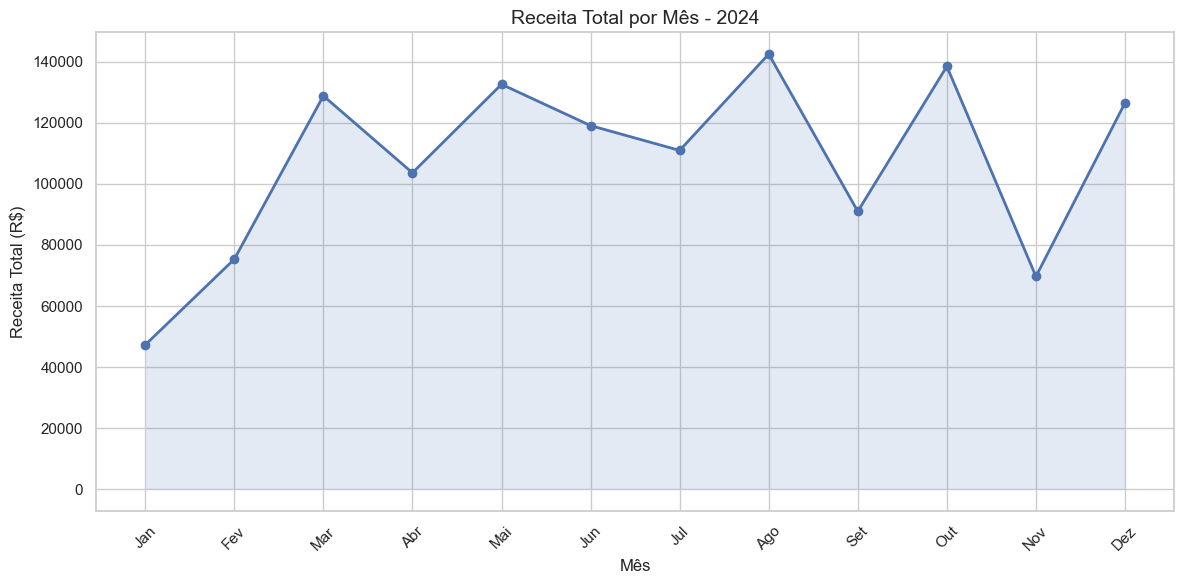

Gráfico exportado: outputs/graficos\vendas_por_mes.png


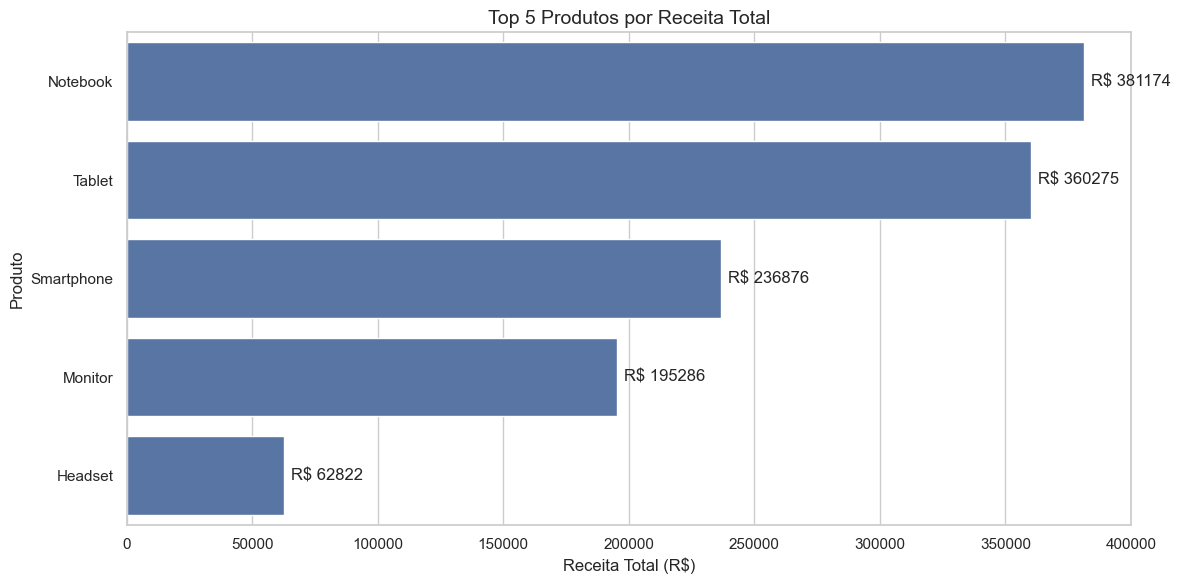

Gráfico exportado: outputs/graficos\top_produtos.png


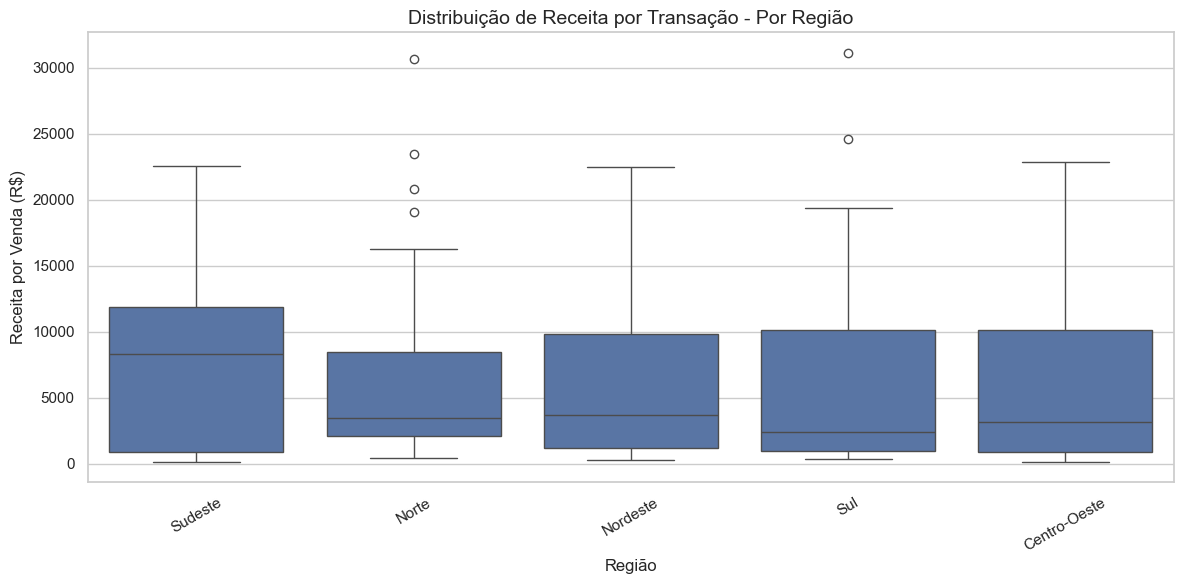

Gráfico exportado: outputs/graficos\distribuicao_regioes.png

=== VISUALIZAÇÕES GERADAS COM SUCESSO ===

[AnalisadorDeVendas] Relatório exportado: outputs/relatorio_resumo.csv

=== ESTATÍSTICAS COM NUMPY ===
Receita média por venda: R$ 6559.66
Receita mediana por venda: R$ 3591.18
Desvio padrão: R$ 6625.37
Receita total: R$ 1285694.32
Percentil 25: R$ 1096.07
Percentil 75: R$ 10657.42

Receitas normalizadas — primeiros 5 valores:
[0.0024 0.0443 0.1512 0.3184 0.027 ]

Vendas acima da média: 78 de 196
CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

Conteúdo do JSON exportado:
{
  "media": "R$ 6.559,66",
  "mediana": "R$ 3.591,18",
  "desvio_padrao": "R$ 6.625,37",
  "total": "R$ 1.285.694,32",
  "percentil_25": "R$ 1.096,07",
  "percentil_75": "R$ 10.657,42"
}

=== GERANDO GRÁFICOS COMPLEMENTARES ===


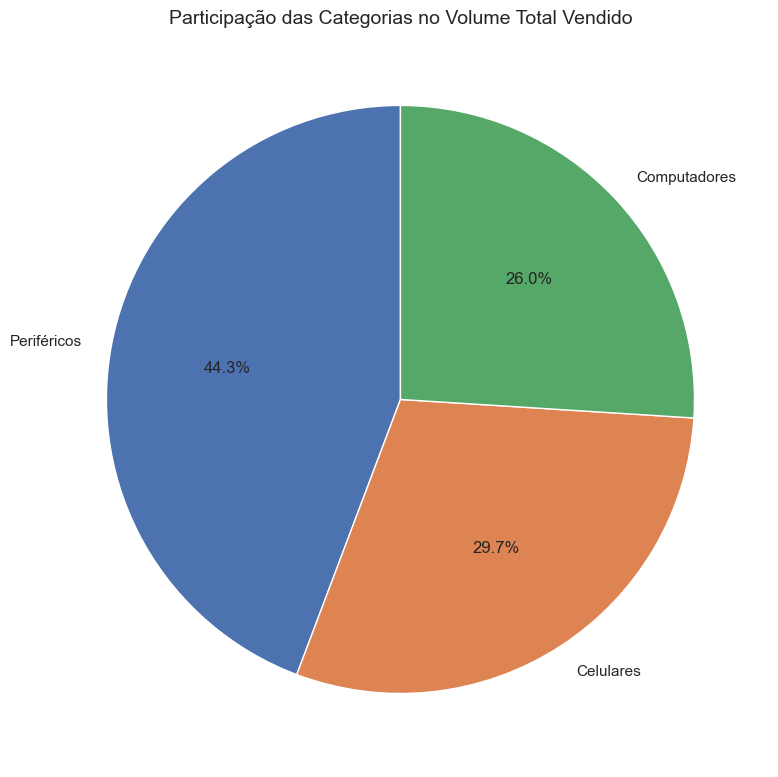

Gráfico exportado: outputs/graficos\pizza_categoria_volume_total.png


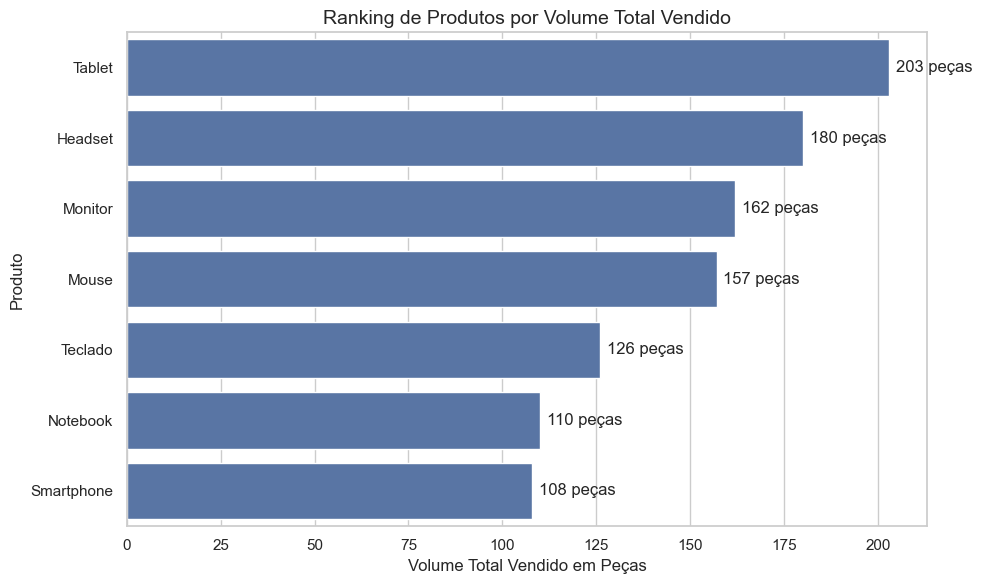

Gráfico exportado: outputs/graficos\ranking_produtos_volume_total.png


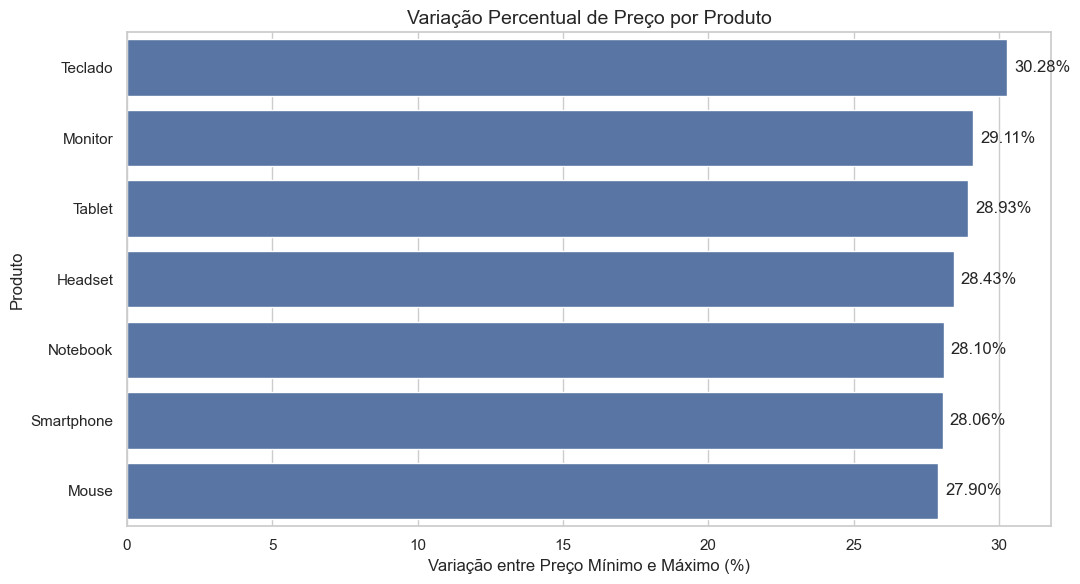

Gráfico exportado: outputs/graficos\variacao_percentual_preco_por_produto.png

Tabela de variação percentual de preço por produto:


,produto,preco_minimo,preco_medio,preco_maximo,variacao_percentual
6,Teclado,"R$ 213,87","R$ 242,19","R$ 287,21","30,28%"
1,Monitor,"R$ 1.022,12","R$ 1.204,98","R$ 1.372,89","29,11%"
5,Tablet,"R$ 1.534,42","R$ 1.791,12","R$ 2.052,56","28,93%"
0,Headset,"R$ 301,27","R$ 346,71","R$ 399,83","28,43%"
3,Notebook,"R$ 2.996,90","R$ 3.467,02","R$ 3.970,97","28,10%"
4,Smartphone,"R$ 1.899,30","R$ 2.167,12","R$ 2.507,29","28,06%"
2,Mouse,"R$ 102,90","R$ 121,82","R$ 136,89","27,90%"


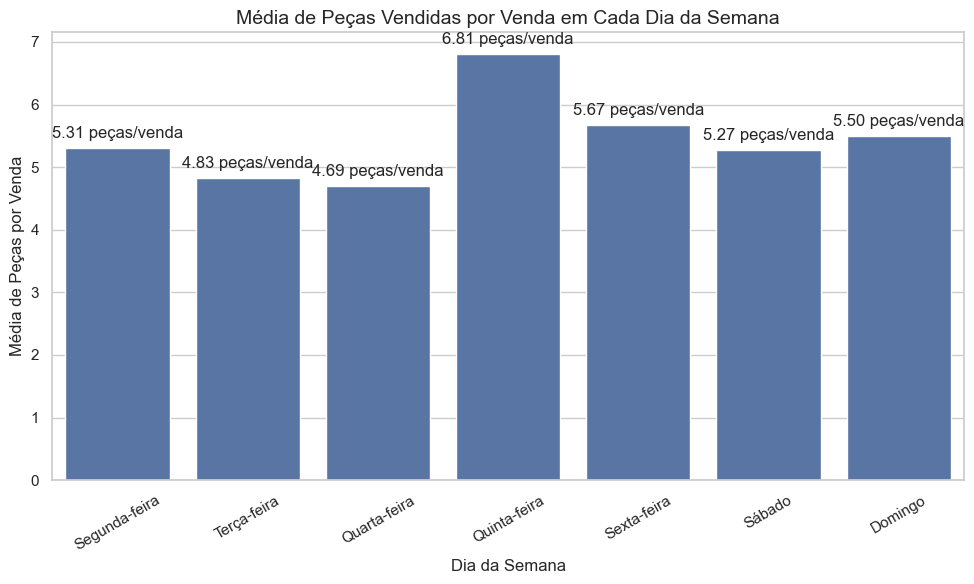

Gráfico exportado: outputs/graficos\media_pecas_por_venda_dia_semana.png

Tabela de média de peças por venda por dia da semana:


,dia_semana,numero_vendas,media_pecas_por_venda
0,Segunda-feira,29,"5,31"
1,Terça-feira,23,"4,83"
2,Quarta-feira,36,"4,69"
3,Quinta-feira,16,"6,81"
4,Sexta-feira,27,"5,67"
5,Sábado,33,"5,27"
6,Domingo,32,"5,50"


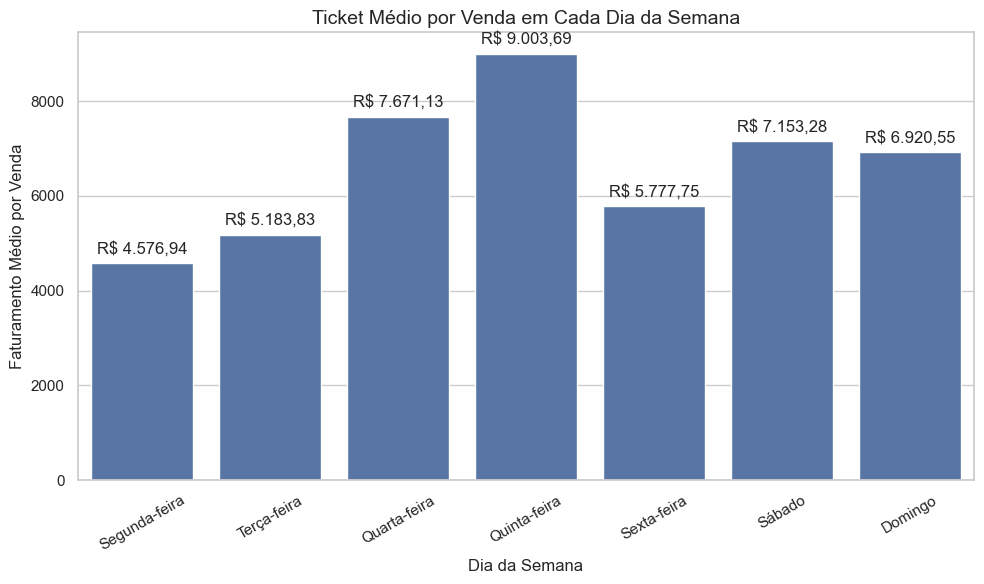

Gráfico exportado: outputs/graficos\ticket_medio_dia_semana.png

Tabela de ticket médio por dia da semana:


,dia_semana,numero_vendas,ticket_medio
0,Segunda-feira,29,"R$ 4.576,94"
1,Terça-feira,23,"R$ 5.183,83"
2,Quarta-feira,36,"R$ 7.671,13"
3,Quinta-feira,16,"R$ 9.003,69"
4,Sexta-feira,27,"R$ 5.777,75"
5,Sábado,33,"R$ 7.153,28"
6,Domingo,32,"R$ 6.920,55"



=== GRÁFICOS COMPLEMENTARES GERADOS COM SUCESSO ===

=== GERANDO RANKINGS DE CLIENTES ===
RELATÓRIO - TOP 3 CLIENTES POR MÊS


mes_ano,posicao,cliente,valor_comprado
janeiro/2024,🏆 1º,Cliente_032,"R$ 15.019,20"
janeiro/2024,2º,Cliente_011,"R$ 11.259,06"
janeiro/2024,3º,Cliente_022,"R$ 8.316,91"
fevereiro/2024,🏆 1º,Cliente_024,"R$ 15.591,77"
fevereiro/2024,2º,Cliente_035,"R$ 15.066,27"
fevereiro/2024,3º,Cliente_015,"R$ 12.544,17"
março/2024,🏆 1º,Cliente_046,"R$ 22.217,52"
março/2024,2º,Cliente_002,"R$ 20.034,63"
março/2024,3º,Cliente_023,"R$ 16.150,96"
abril/2024,🏆 1º,Cliente_016,"R$ 24.570,08"


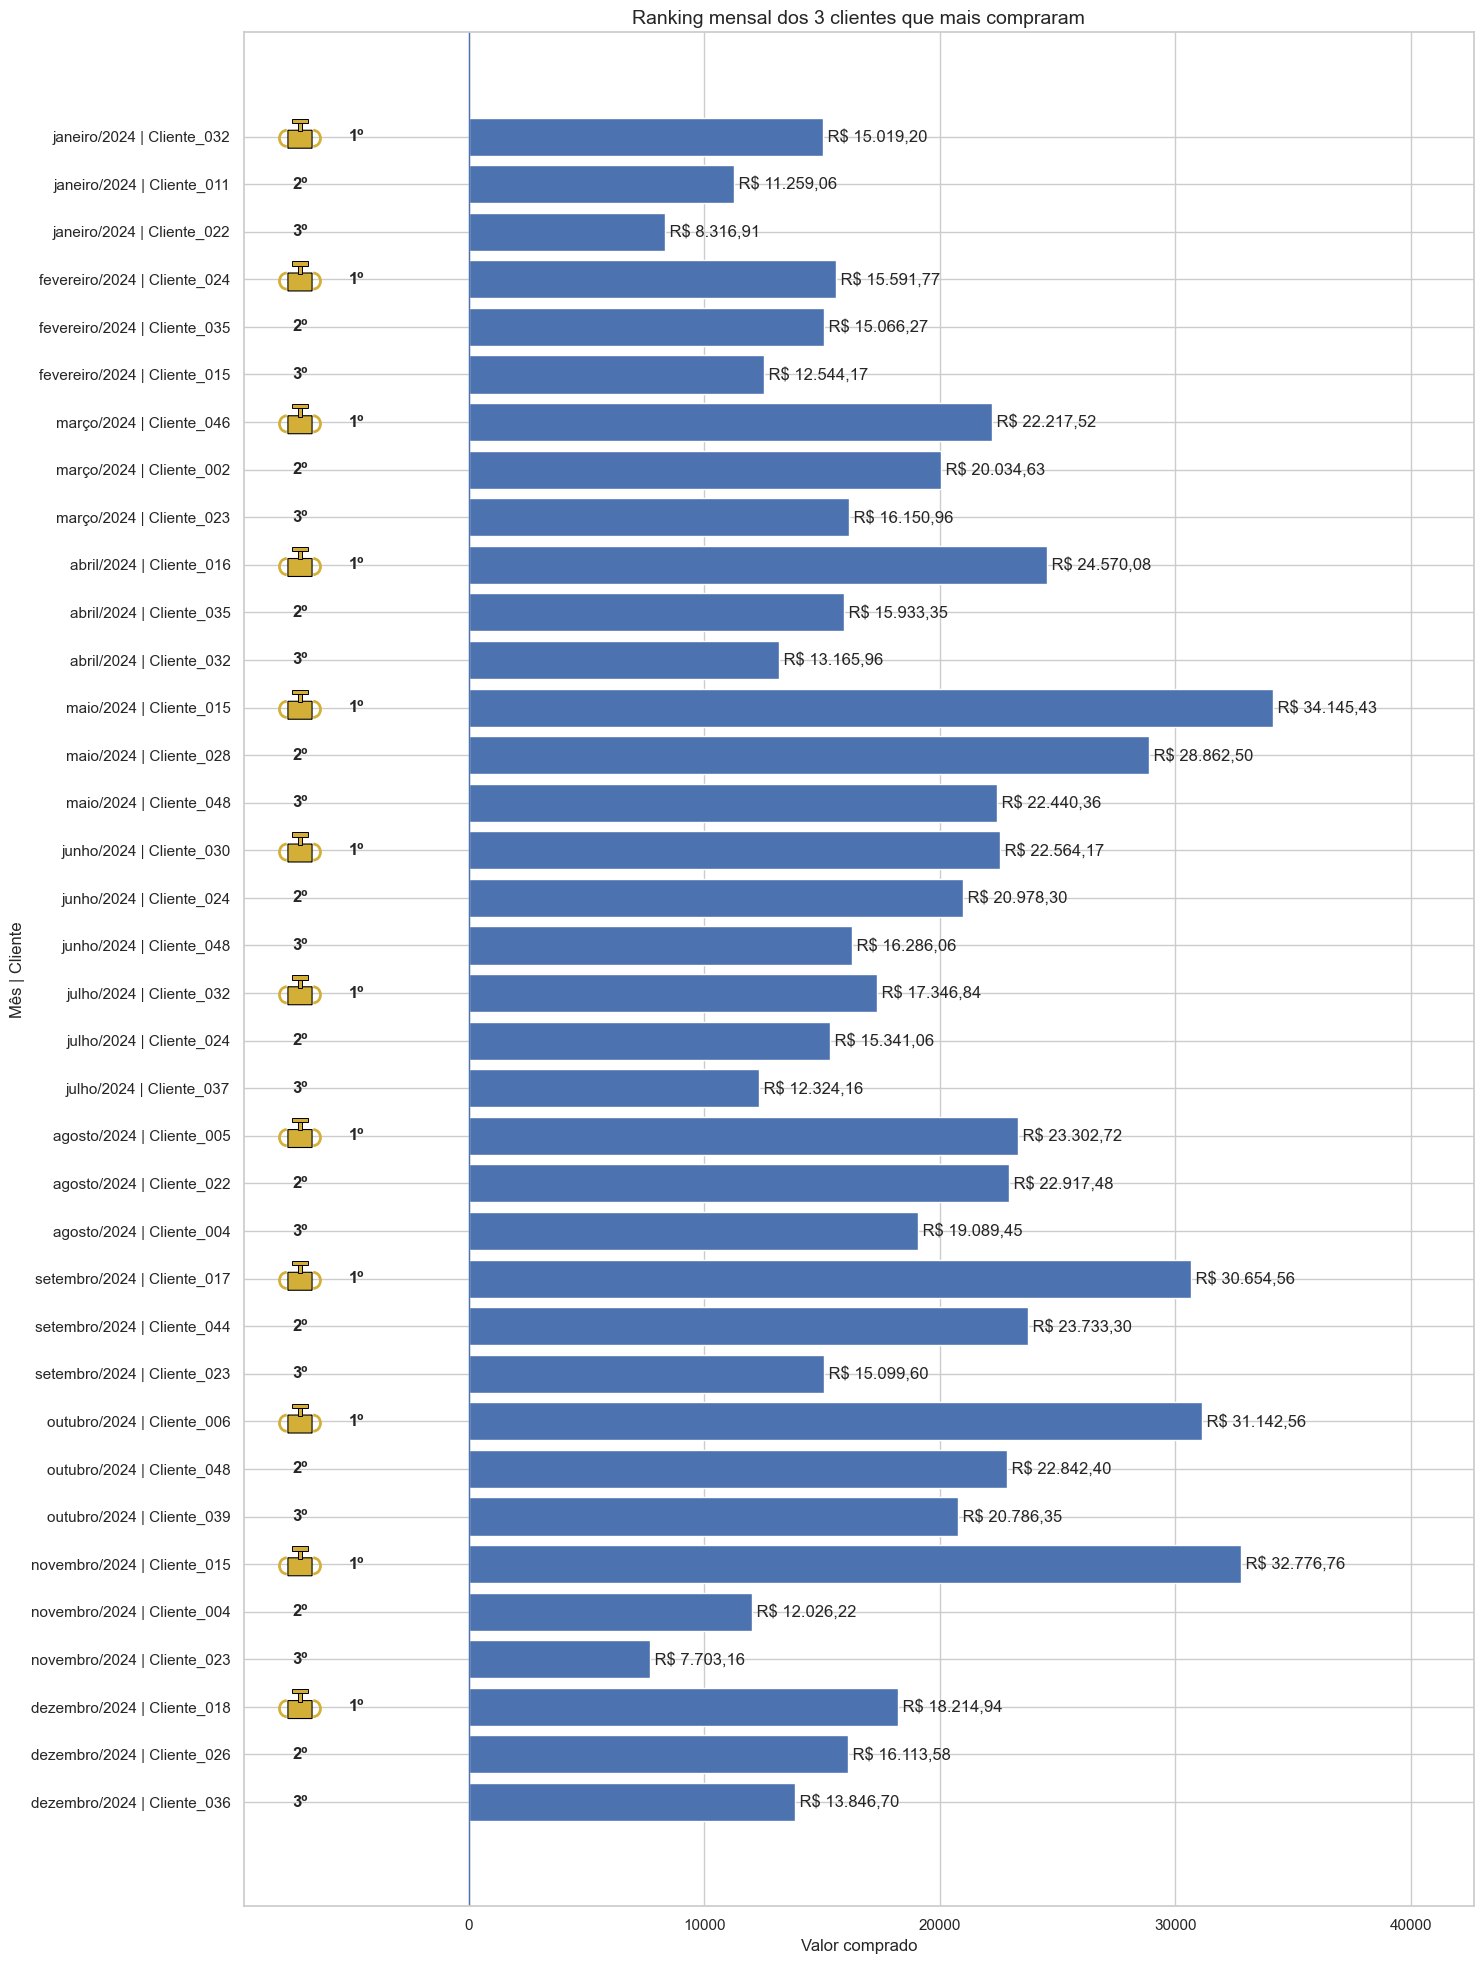

RELATÓRIO - TOP 3 CLIENTES DO ANO DE 2024


ano,posicao,cliente,valor_comprado
2024,🏆 1º,Cliente_015,"R$ 82.964,76"
2024,2º,Cliente_035,"R$ 75.402,52"
2024,3º,Cliente_048,"R$ 64.324,93"


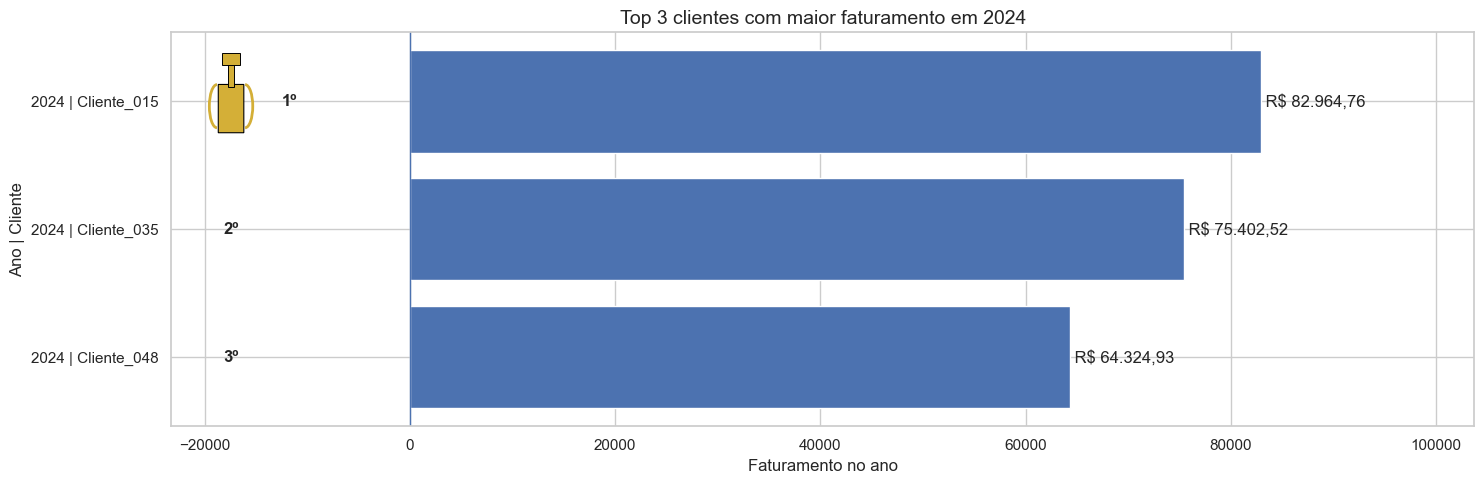

Relatório mensal CSV exportado para:
C:\Users\renat\OneDrive\Documentos\SENAI\MINIPROJETO\salesinsight-py\outputs\relatorio_top3_clientes_por_mes.csv

Gráfico mensal PNG exportado para:
C:\Users\renat\OneDrive\Documentos\SENAI\MINIPROJETO\salesinsight-py\outputs\graficos\grafico_top3_clientes_por_mes.png

Relatório anual CSV exportado para:
C:\Users\renat\OneDrive\Documentos\SENAI\MINIPROJETO\salesinsight-py\outputs\relatorio_top3_clientes_ano_2024.csv

Gráfico anual PNG exportado para:
C:\Users\renat\OneDrive\Documentos\SENAI\MINIPROJETO\salesinsight-py\outputs\graficos\grafico_top3_clientes_ano_2024.png

=== GERANDO RELATÓRIO DE DESCONTO TOP 10 CLIENTES ===
Coluna 'desconto' criada com sucesso.

=== TOP 10 CLIENTES COM MAIOR FATURAMENTO EM 2024 ===


posicao,cliente,faturamento_ano_br,desconto_percentual,valor_desconto_br,faturamento_com_desconto_br
🏆 1º,Cliente_015,"R$ 82.964,76",10%,"R$ 8.296,48","R$ 74.668,28"
2º,Cliente_035,"R$ 75.402,52",10%,"R$ 7.540,25","R$ 67.862,27"
3º,Cliente_048,"R$ 64.324,93",10%,"R$ 6.432,49","R$ 57.892,44"
4º,Cliente_024,"R$ 57.381,21",10%,"R$ 5.738,12","R$ 51.643,09"
5º,Cliente_006,"R$ 50.249,74",10%,"R$ 5.024,97","R$ 45.224,77"
6º,Cliente_004,"R$ 50.106,56",10%,"R$ 5.010,66","R$ 45.095,90"
7º,Cliente_023,"R$ 46.863,73",5%,"R$ 2.343,19","R$ 44.520,54"
8º,Cliente_030,"R$ 45.659,41",5%,"R$ 2.282,97","R$ 43.376,44"
9º,Cliente_032,"R$ 45.532,00",5%,"R$ 2.276,60","R$ 43.255,40"
10º,Cliente_044,"R$ 43.513,88",5%,"R$ 2.175,69","R$ 41.338,19"



Relatório de desconto dos Top 10 clientes exportado para:
C:\Users\renat\OneDrive\Documentos\SENAI\MINIPROJETO\salesinsight-py\outputs\relatorio_desconto_top10_clientes_2024.csv

RESUMO EXECUTIVO - SALESINSIGHT PY
Arquivo analisado: vendas.csv
Registros brutos: 200
Registros limpos: 196
Receita total anual: R$ 1.285.694,32
Cliente top: Cliente_015 - R$ 82.964,76

=== DETALHAMENTO DAS PROJEÇÕES ===
Janeiro: R$ 114.540,02
Fevereiro: R$ 117.539,35
Março: R$ 120.538,69

[CONCLUÍDO] Pipeline finalizado com sucesso!


In [37]:
# ============================================================
# EXECUÇÃO DO PIPELINE COMPLETO
# ============================================================

resultado_pipeline = main()

analisador = resultado_pipeline["analisador"]
df_limpo = resultado_pipeline["df_limpo"]
metricas = resultado_pipeline["metricas"]
clientes = resultado_pipeline["clientes"]
stats = resultado_pipeline["stats"]
projecoes = resultado_pipeline["projecoes"]

resultados_rankings_clientes = resultado_pipeline["resultados_rankings_clientes"]
relatorio_top3_clientes_mes = resultado_pipeline["relatorio_top3_clientes_mes"]
relatorio_top3_clientes_ano = resultado_pipeline["relatorio_top3_clientes_ano"]
relatorio_desconto_top10_clientes_2024 = resultado_pipeline["relatorio_desconto_top10_clientes_2024"]